#  Automated Tuberculosis Detection from Chest X-Ray Images
## Complete Machine Learning Pipeline with Explainable AI (XAI)



---
### Pipeline at a Glance
| Step | Description |
|------|-------------|
| 1 | Data Loading & Cleaning (duplicates, corrupt files) |
| 2 | Rich Feature Extraction (21 features per image) |
| 3 | Exploratory Data Analysis (15+ visualisations) |
| 4 | Preprocessing – Stratified Split, SMOTE, Scaling |
| 5 | 8 Machine Learning Models |
| 6 | Rigorous Evaluation – PR-AUC, Recall, F1, ROC-AUC |
| 7 | XAI – SHAP (tree models), LIME (classical), Grad-CAM (CNN) |


In [78]:
import os, cv2, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# Image features 
from skimage.feature import graycomatrix, graycoprops, hog
from skimage.filters import sobel
from scipy.stats import skew, kurtosis, entropy as sp_entropy

#  Classical ML 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import xgboost as xgb

#  Imbalance 
from imblearn.over_sampling import SMOTE

#  XAI 
import shap
import lime, lime.lime_tabular

#  Deep Learning 
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, GlobalAveragePooling2D,
)
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries loaded")
print(f"   TensorFlow : {tf.__version__}")
print(f"   NumPy      : {np.__version__}")


All libraries loaded
   TensorFlow : 2.19.0
   NumPy      : 2.1.3


In [79]:
# 
#  CONFIGURATION  – update DATASET_PATH 
# 

DATASET_PATH = (
    "C:/Users/H P/OneDrive/Desktop/TUBERCULOSIS-DETECTION-ML/TB_Chest_Radiography_Database"
)

CLASSES       = ["Normal", "Tuberculosis"]
IMG_SIZE      = 128     # for classical-ML feature extraction
IMG_SIZE_CNN  = 224     # DenseNet-121 standard input
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
VAL_SIZE      = 0.10
BATCH_SIZE    = 32
EPOCHS        = 40      # early stopping will cut this short

PALETTE = {"Normal": "#2ecc71", "Tuberculosis": "#e74c3c"}
print(" Config ready.")


 Config ready.


##  1: Data Loading

In [80]:
image_paths, labels = [], []

for label in CLASSES:
    folder = os.path.join(DATASET_PATH, label)
    if not os.path.exists(folder):
        print(f"  Folder missing: {folder}")
        continue
    for f in sorted(os.listdir(folder)):
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(folder, f))
            labels.append(label)

df = pd.DataFrame({"image_path": image_paths, "label": labels})
print(f"Total images loaded : {len(df)}")
print(df["label"].value_counts().to_string())
ratio = df["label"].value_counts()
print(f"\nClass ratio Normal:TB = {ratio['Normal']}:{ratio['Tuberculosis']}  "
      f"({ratio['Normal']/ratio['Tuberculosis']:.1f}:1 imbalance)")


Total images loaded : 4200
label
Normal          3500
Tuberculosis     700

Class ratio Normal:TB = 3500:700  (5.0:1 imbalance)


##  2: Data Cleaning

In [81]:
#   Missing files 
missing = df[~df["image_path"].apply(os.path.exists)]
print(f"Missing files   : {len(missing)}")

#   Corrupt images 
corrupt = []
for path in tqdm(df["image_path"], desc="Corruption check"):
    try:
        img = Image.open(path)
        img.verify()
    except Exception:
        corrupt.append(path)
print(f"Corrupt images  : {len(corrupt)}")

#  Duplicate images (MD5 hash) 
def file_hash(p):
    with open(p, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["hash"] = df["image_path"].apply(file_hash)
n_dup = df.duplicated("hash").sum()
print(f"Duplicate images: {n_dup}  → dropping")

df = df[~df.duplicated("hash")].drop(columns=["hash"]).reset_index(drop=True)
print(f"\n Clean dataset : {len(df)} images")
print(df["label"].value_counts().to_string())


Missing files   : 0


Corruption check: 100%|██████████| 4200/4200 [00:10<00:00, 415.27it/s]


Corrupt images  : 0
Duplicate images: 3  → dropping

 Clean dataset : 4197 images
label
Normal          3500
Tuberculosis     697


##   3: Rich Feature Extraction (21 features per image)

In [82]:
# Features extracted
# 
# Global stats  (10): mean, std, min, max, median, p25, p75,
#                     skewness, kurtosis, entropy
# GLCM texture  ( 5): contrast, correlation, energy,
#                     homogeneity, dissimilarity
# Edge/Sobel    ( 2): edge_mean, edge_std
# FFT frequency ( 2): fft_mean, fft_std
# HOG summary   ( 2): hog_mean, hog_std
# 

FEATURE_NAMES = [
    "mean_pixel", "std_pixel", "min_pixel", "max_pixel", "median_pixel",
    "p25", "p75", "skewness", "kurt", "entropy",
    "glcm_contrast", "glcm_correlation", "glcm_energy",
    "glcm_homogeneity", "glcm_dissimilarity",
    "edge_mean", "edge_std",
    "fft_mean", "fft_std",
    "hog_mean", "hog_std",
]

def extract_features(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    #  Global pixel statistics 
    flat = img.flatten().astype(np.float64)
    hist, _ = np.histogram(flat, bins=256, range=(0, 256), density=True)
    hist += 1e-10

    stats = [
        float(np.mean(flat)),
        float(np.std(flat)),
        float(np.min(flat)),
        float(np.max(flat)),
        float(np.median(flat)),
        float(np.percentile(flat, 25)),
        float(np.percentile(flat, 75)),
        float(skew(flat)),
        float(kurtosis(flat)),
        float(sp_entropy(hist)),
    ]

    #  GLCM texture 
    glcm = graycomatrix(
        img.astype(np.uint8), distances=[1], angles=[0],
        levels=256, symmetric=True, normed=True,
    )
    texture = [
        float(graycoprops(glcm, "contrast")[0, 0]),
        float(graycoprops(glcm, "correlation")[0, 0]),
        float(graycoprops(glcm, "energy")[0, 0]),
        float(graycoprops(glcm, "homogeneity")[0, 0]),
        float(graycoprops(glcm, "dissimilarity")[0, 0]),
    ]

    #  Edge density (Sobel) 
    norm = img.astype(np.float64) / 255.0
    edges = sobel(norm)
    edge = [float(np.mean(edges)), float(np.std(edges))]

    #  Frequency (2-D FFT) 
    fft_mag = np.abs(np.fft.fft2(norm))
    freq = [float(np.mean(fft_mag)), float(np.std(fft_mag))]

    #  HOG summary 
    hog_desc = hog(
        norm, orientations=8, pixels_per_cell=(16, 16),
        cells_per_block=(1, 1), visualize=False,
    )
    hog_feats = [float(np.mean(hog_desc)), float(np.std(hog_desc))]

    return stats + texture + edge + freq + hog_feats


print(f"Extracting {len(FEATURE_NAMES)} features from {len(df)} images …")
feats = [extract_features(p) for p in tqdm(df["image_path"], desc="Features")]

feat_df = pd.DataFrame(feats, columns=FEATURE_NAMES)
df = pd.concat([df, feat_df], axis=1)
df["label_enc"] = (df["label"] == "Tuberculosis").astype(int)

print(f"\nDone. Feature matrix shape: {feat_df.shape}")
print("Sample (first 3 rows):")
print(feat_df.head(3).to_string())


Extracting 21 features from 4197 images …


Features: 100%|██████████| 4197/4197 [01:30<00:00, 46.14it/s]


Done. Feature matrix shape: (4197, 21)
Sample (first 3 rows):
   mean_pixel  std_pixel  min_pixel  max_pixel  median_pixel   p25    p75  skewness      kurt   entropy  glcm_contrast  glcm_correlation  glcm_energy  glcm_homogeneity  glcm_dissimilarity  edge_mean  edge_std  fft_mean    fft_std  hog_mean   hog_std
0  102.657715  53.629685        0.0      224.0         104.0  70.0  135.0 -0.061887 -0.510054  5.149780      80.251476          0.986014     0.045844          0.284676            5.106668   0.031989  0.033394  5.520965  57.875395  0.305270  0.178354
1  118.221741  65.423899        0.0      249.0         120.0  66.0  170.0 -0.024573 -1.038987  5.387264     134.482406          0.984217     0.023225          0.220738            7.304626   0.053916  0.061335  6.885073  67.473180  0.307048  0.175276
2  109.916504  44.004390        0.0      196.0         114.0  89.0  134.0 -0.564678  0.314557  4.977563      58.935839          0.984706     0.031222          0.278398            4.402375

##  Section 4: Exploratory Data Analysis (EDA)

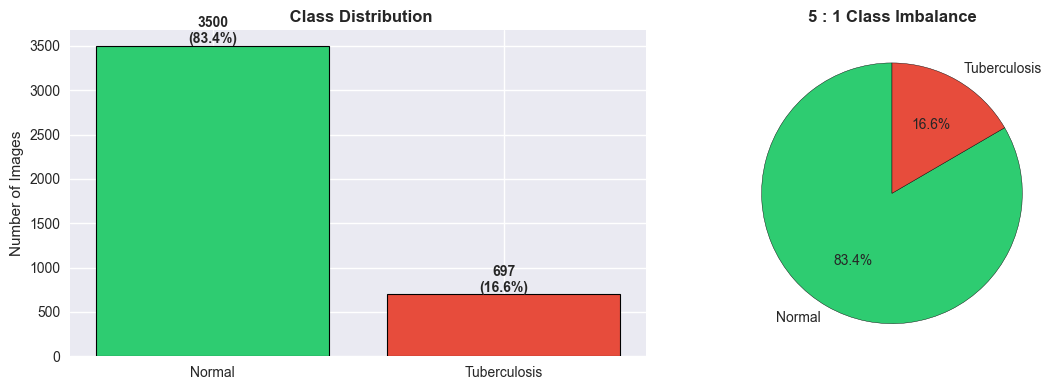

In [83]:
#   Class distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["label"].value_counts()
bars = axes[0].bar(
    counts.index, counts.values,
    color=[PALETTE["Normal"], PALETTE["Tuberculosis"]],
    edgecolor="black", linewidth=0.8,
)
for bar, v in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        v + 30,
        f"{v}\n({v / len(df) * 100:.1f}%)",
        ha="center", fontweight="bold", fontsize=10,
    )
axes[0].set_title(" Class Distribution", fontweight="bold")
axes[0].set_ylabel("Number of Images")

axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=[PALETTE["Normal"], PALETTE["Tuberculosis"]],
    startangle=90,
    wedgeprops={"edgecolor": "black"},
)
axes[1].set_title("5 : 1 Class Imbalance", fontweight="bold")

plt.tight_layout()
plt.savefig("fig1_class_dist.png", dpi=150, bbox_inches="tight")
plt.show()



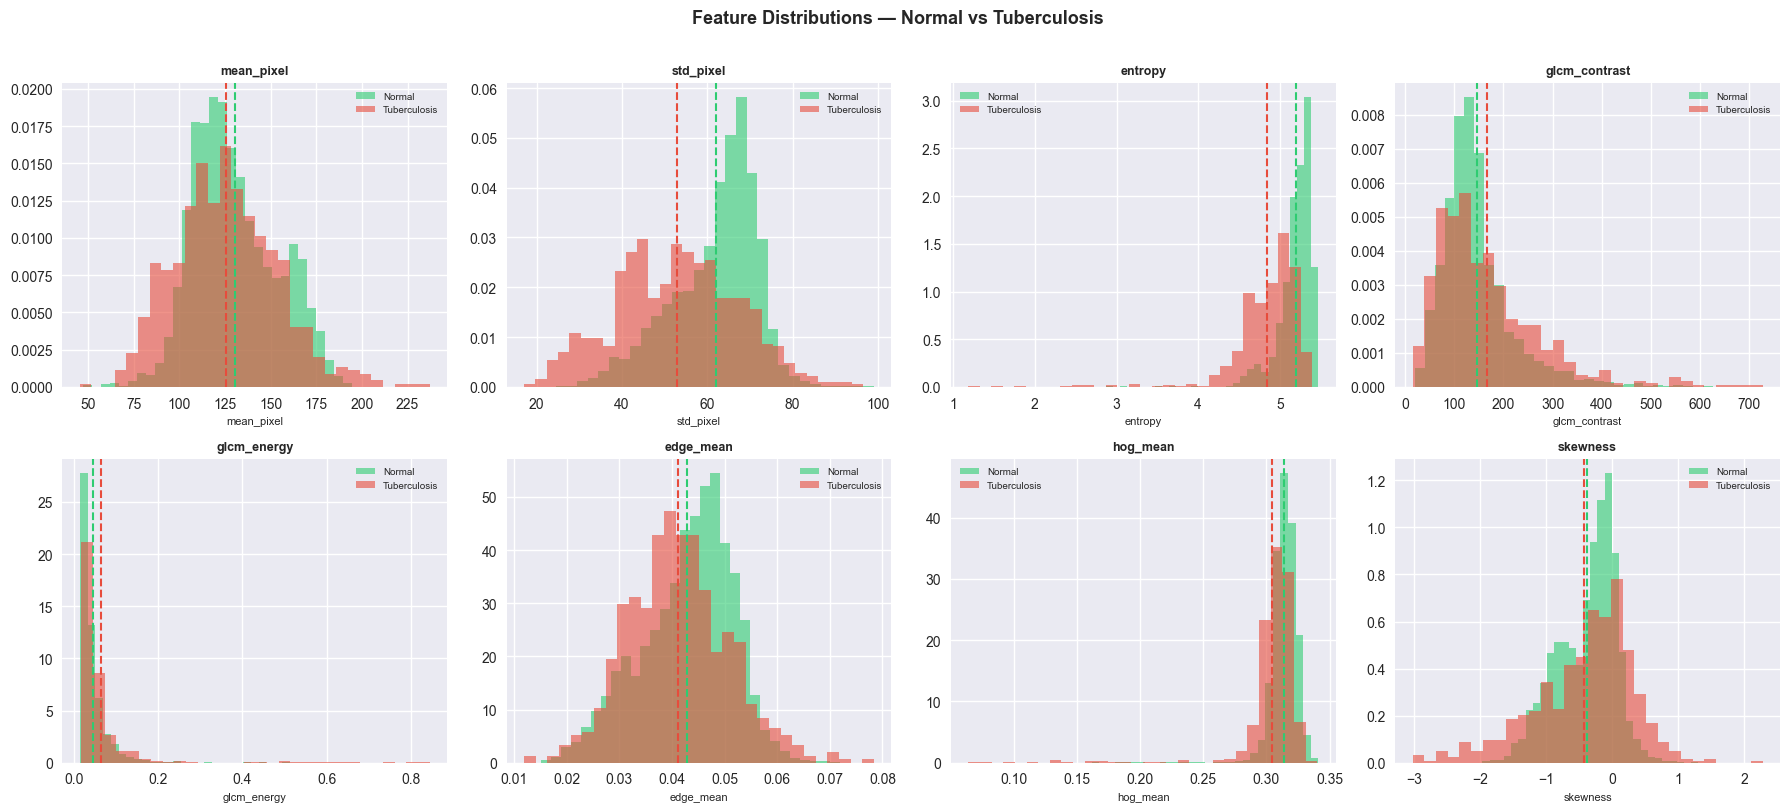

In [84]:
#   Feature distributions by class 
key_feats = [
    "mean_pixel", "std_pixel", "entropy", "glcm_contrast",
    "glcm_energy", "edge_mean", "hog_mean", "skewness",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flatten(), key_feats):
    for lbl, col in PALETTE.items():
        sub = df[df["label"] == lbl][feat]
        ax.hist(sub, bins=30, alpha=0.6, color=col, label=lbl, density=True)
        ax.axvline(sub.mean(), color=col, linestyle="--", linewidth=1.5)
    ax.set_title(feat, fontweight="bold", fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle(" Feature Distributions — Normal vs Tuberculosis",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig2_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


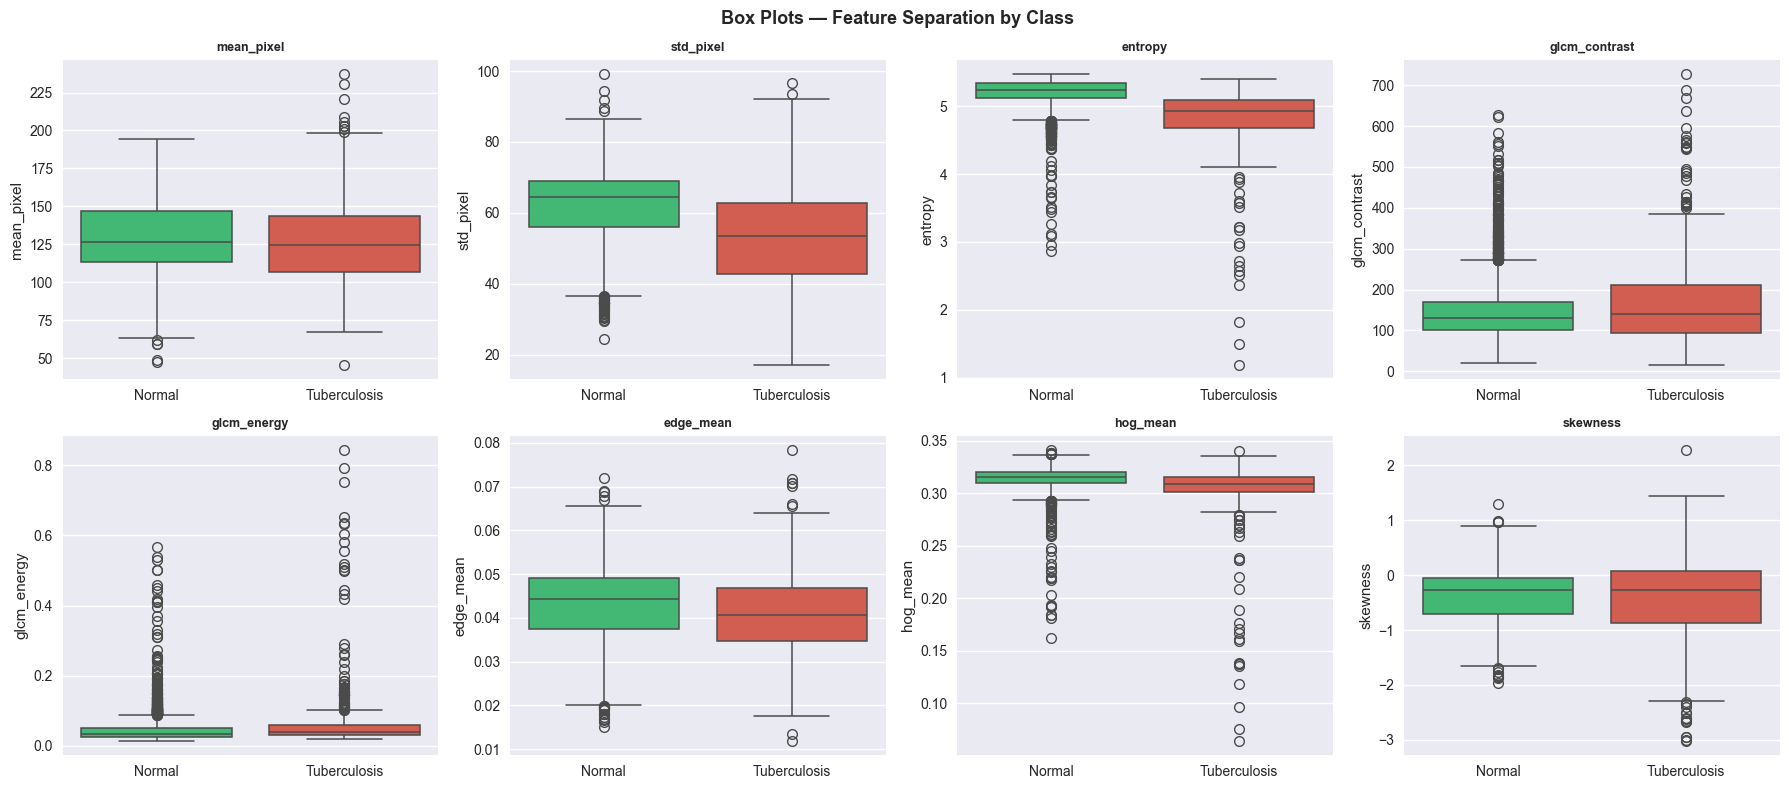

In [85]:
# 4.3  Box plots 
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flatten(), key_feats):
    sns.boxplot(x="label", y=feat, data=df, ax=ax, palette=PALETTE, linewidth=1.1)
    ax.set_title(feat, fontweight="bold", fontsize=9)
    ax.set_xlabel("")

plt.suptitle(" Box Plots — Feature Separation by Class",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


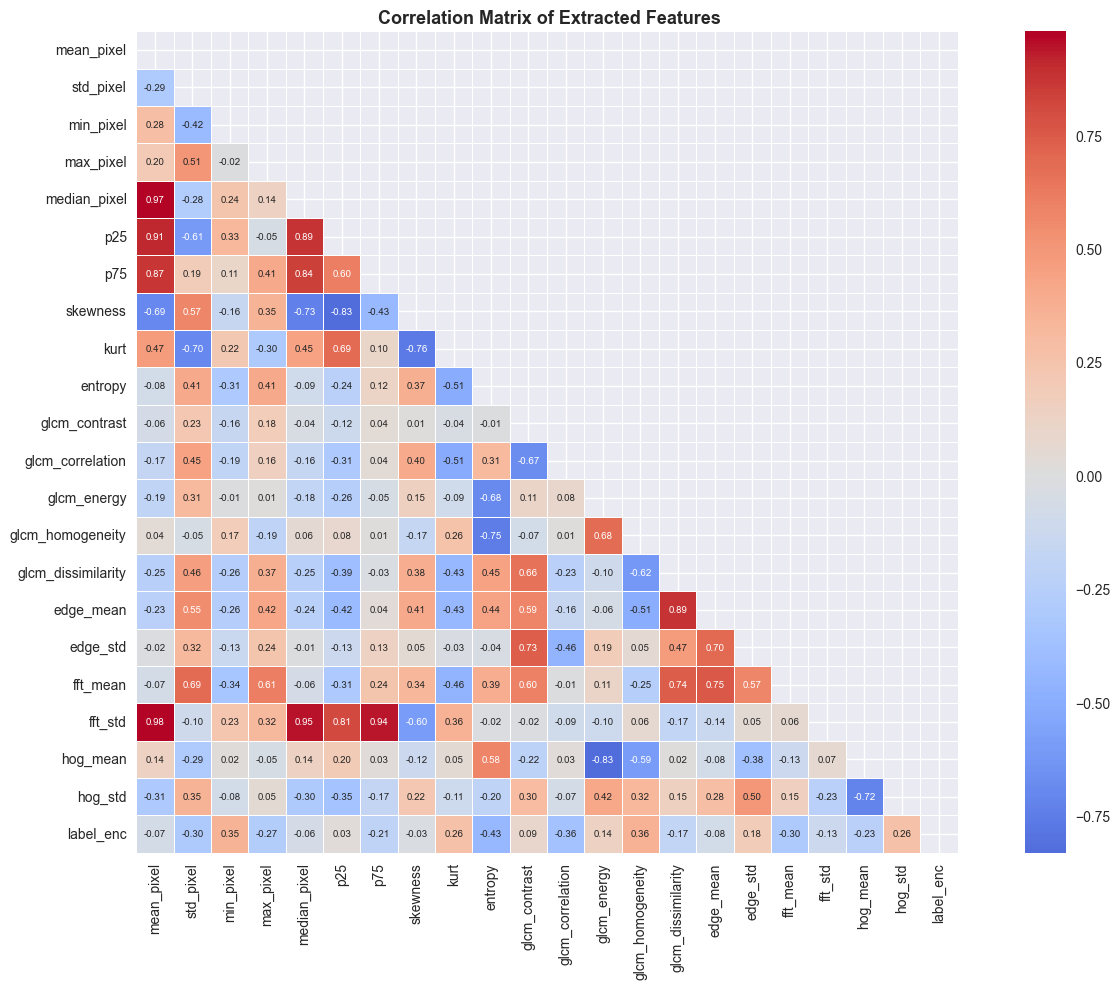

Top 8 features correlated with TB label:
entropy             0.434846
glcm_homogeneity    0.361943
glcm_correlation    0.357909
min_pixel           0.353829
fft_mean            0.299621
std_pixel           0.296137
max_pixel           0.271508
hog_std             0.263149


In [86]:
#  4.4  Correlation matrix 
plt.figure(figsize=(14, 10))
corr = df[FEATURE_NAMES + ["label_enc"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.4, annot_kws={"size": 7})
plt.title(" Correlation Matrix of Extracted Features",
          fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("fig4_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

top_corr = corr["label_enc"].drop("label_enc").abs().sort_values(ascending=False)
print("Top 8 features correlated with TB label:")
print(top_corr.head(8).to_string())


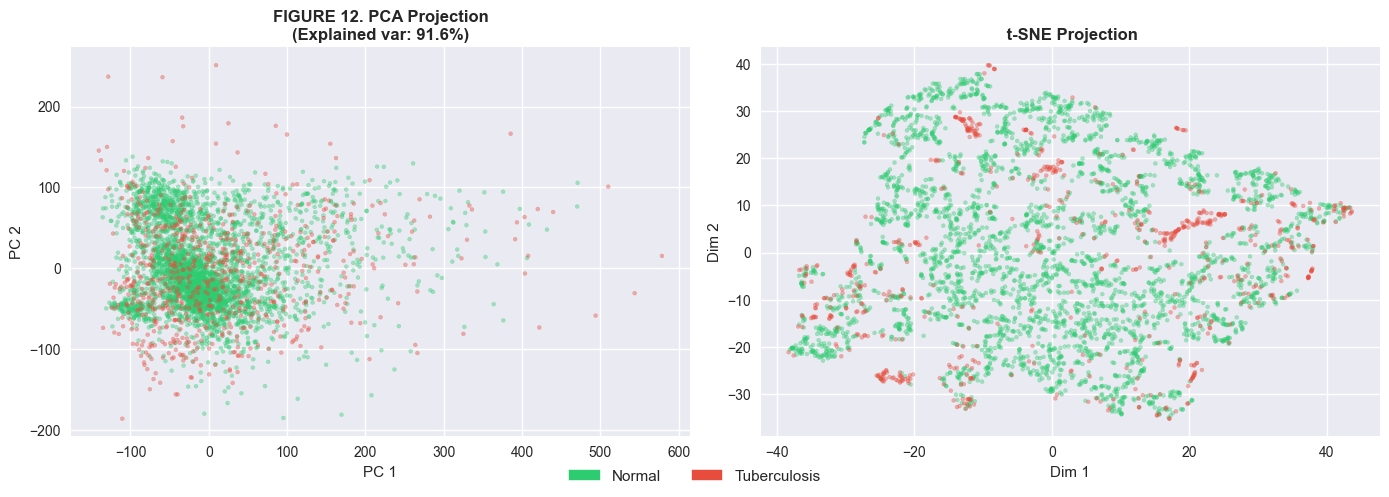

In [87]:
#  4.5  PCA & t-SNE 2-D projections 
X_all = df[FEATURE_NAMES].values
y_all = df["label_enc"].values
point_colors = [PALETTE["Tuberculosis"] if y else PALETTE["Normal"] for y in y_all]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
proj_pca = pca2.fit_transform(X_all)
axes[0].scatter(proj_pca[:, 0], proj_pca[:, 1], c=point_colors, alpha=0.4, s=8)
axes[0].set_title(
    f"FIGURE 12. PCA Projection\n"
    f"(Explained var: {pca2.explained_variance_ratio_.sum():.1%})",
    fontweight="bold",
)
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")

tsne2 = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=500)
proj_tsne = tsne2.fit_transform(X_all)
axes[1].scatter(proj_tsne[:, 0], proj_tsne[:, 1], c=point_colors, alpha=0.4, s=8)
axes[1].set_title(" t-SNE Projection", fontweight="bold")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")

legend_h = [
    mpatches.Patch(color=PALETTE["Normal"], label="Normal"),
    mpatches.Patch(color=PALETTE["Tuberculosis"], label="Tuberculosis"),
]
fig.legend(handles=legend_h, loc="lower center", ncol=2, fontsize=11)
plt.tight_layout()
plt.savefig("fig5_pca_tsne.png", dpi=150, bbox_inches="tight")
plt.show()


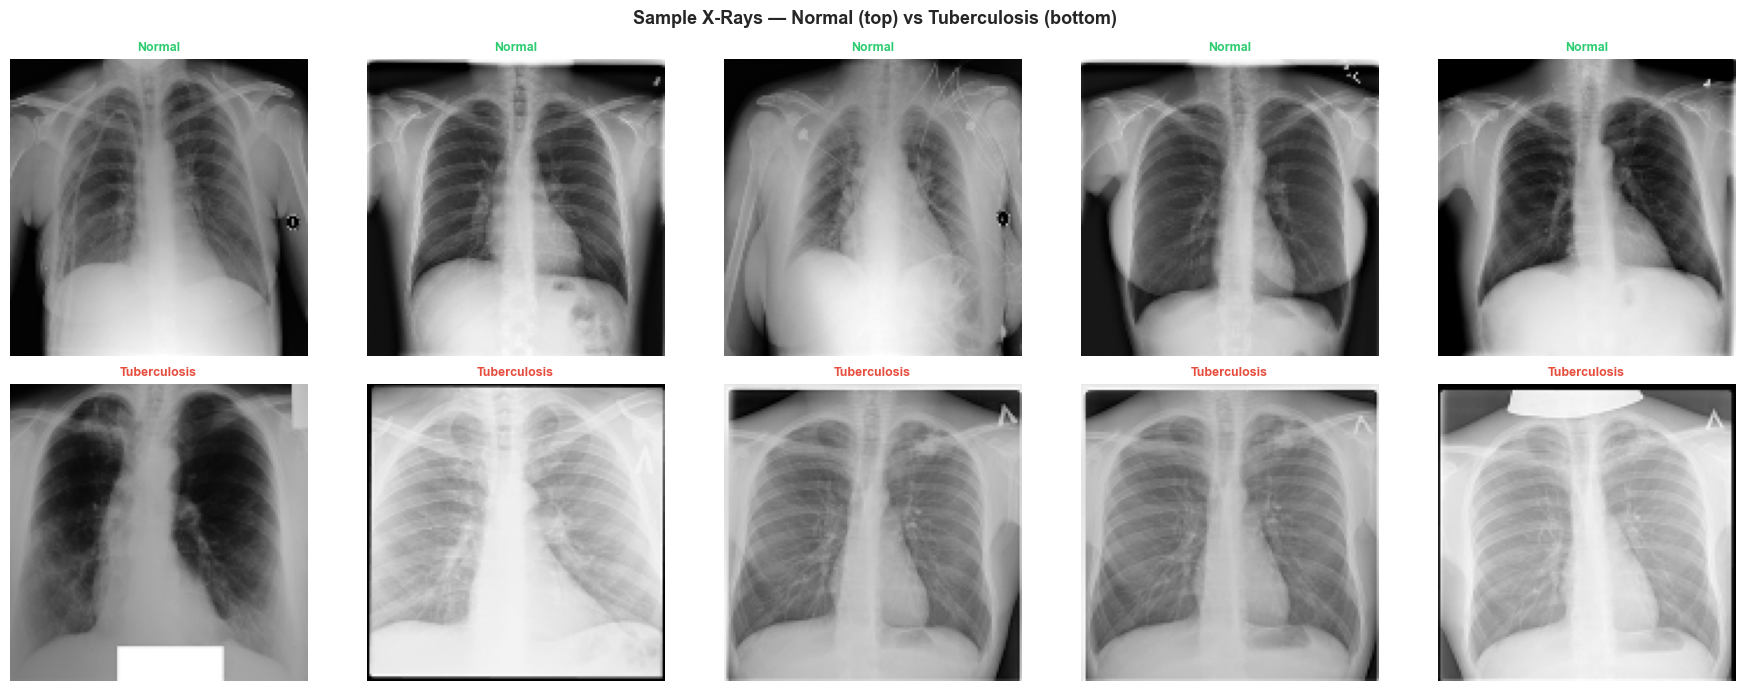

In [88]:
#  4.6  Sample images 
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row_i, (cls, col) in enumerate(PALETTE.items()):
    sample = df[df["label"] == cls].head(5)
    for col_i, (_, r) in enumerate(sample.iterrows()):
        img = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        axes[row_i][col_i].imshow(img, cmap="gray")
        axes[row_i][col_i].set_title(cls, color=col, fontweight="bold", fontsize=9)
        axes[row_i][col_i].axis("off")

plt.suptitle(
    " Sample X-Rays — Normal (top) vs Tuberculosis (bottom)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig("fig6_samples.png", dpi=150, bbox_inches="tight")
plt.show()


## 5: Preprocessing — Split · SMOTE · Scale

In [89]:
#  Stratified 70 / 10 / 20 split 
X = df[FEATURE_NAMES].values
y = df["label_enc"].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    stratify=y_trainval,
    random_state=RANDOM_STATE,
)

print("Dataset split (stratified):")
print(f"  Train : {len(X_train):4d}  — TB: {y_train.sum():3d}  Normal: {(y_train==0).sum()}")
print(f"  Val   : {len(X_val):4d}  — TB: {y_val.sum():3d}  Normal: {(y_val==0).sum()}")
print(f"  Test  : {len(X_test):4d}  — TB: {y_test.sum():3d}  Normal: {(y_test==0).sum()}")


Dataset split (stratified):
  Train : 2937  — TB: 488  Normal: 2449
  Val   :  420  — TB:  70  Normal: 350
  Test  :  840  — TB: 139  Normal: 701


In [90]:
#   SMOTE oversampling (train set ONLY) 
print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print("After  SMOTE:", dict(zip(*np.unique(y_train_sm, return_counts=True))))
print(f"Train set grew: {len(X_train)} → {len(X_train_sm)}")


Before SMOTE: {np.int64(0): np.int64(2449), np.int64(1): np.int64(488)}
After  SMOTE: {np.int64(0): np.int64(2449), np.int64(1): np.int64(2449)}
Train set grew: 2937 → 4898


In [91]:
#   StandardScaler (fit on SMOTE train, apply to all)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(" Scaling complete.")
print(f"   Train mean range: [{X_train_sc.mean(axis=0).min():.4f}, "
      f"{X_train_sc.mean(axis=0).max():.4f}]")


 Scaling complete.
   Train mean range: [-0.0000, 0.0000]


In [92]:

#  Shared helpers — evaluation & plotting


results = {}   # accumulates metrics for all 8 models


def evaluate_model(name, model, Xtr, ytr, Xte, yte, use_proba=True):
    model.fit(Xtr, ytr)
    ypred = model.predict(Xte)
    yprob = (
        model.predict_proba(Xte)[:, 1]
        if use_proba
        else model.decision_function(Xte)
    )
    metrics = dict(
        accuracy  = accuracy_score(yte, ypred),
        precision = precision_score(yte, ypred, zero_division=0),
        recall    = recall_score(yte, ypred, zero_division=0),
        f1        = f1_score(yte, ypred, zero_division=0),
        roc_auc   = roc_auc_score(yte, yprob),
        pr_auc    = average_precision_score(yte, yprob),
    )
    results[name] = dict(model=model, y_pred=ypred, y_prob=yprob, **metrics)

    sep = "=" * 58
    print(f"\n{sep}\n  {name}\n{sep}")
    print(classification_report(yte, ypred, target_names=["Normal", "Tuberculosis"]))
    print(f"  ROC-AUC : {metrics['roc_auc']:.4f}   PR-AUC : {metrics['pr_auc']:.4f}")
    return model


def plot_evaluation(name, yte, ypred, yprob):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Confusion matrix
    cm = confusion_matrix(yte, ypred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["Normal", "TB"], yticklabels=["Normal", "TB"])
    axes[0].set_title(f"{name}\nConfusion Matrix", fontweight="bold")
    axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

    # ROC curve
    fpr, tpr, _ = roc_curve(yte, yprob)
    auc_v = roc_auc_score(yte, yprob)
    axes[1].plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC={auc_v:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1)
    axes[1].set_title(f"{name}\nROC Curve", fontweight="bold")
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

    # Precision-Recall curve
    prec_c, rec_c, _ = precision_recall_curve(yte, yprob)
    pr_v = average_precision_score(yte, yprob)
    axes[2].plot(rec_c, prec_c, lw=2, color="darkorange", label=f"PR-AUC={pr_v:.3f}")
    #axes[2].axhline(y=yte.mean(), color="k", linestyle="--", lw=1, label="Baseline")
    axes[2].axhline(y=np.array(yte).mean(), color="k", linestyle="--", lw=1, label="Baseline")
    axes[2].set_title(f"{name}\nPrecision-Recall Curve (Primary)", fontweight="bold")
    axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision"); axes[2].legend()

    plt.tight_layout()
    safe = name.replace(" ", "_").replace("/", "-")
    plt.savefig(f"eval_{safe}.png", dpi=120, bbox_inches="tight")
    plt.show()


print("Helper functions ready.")


Helper functions ready.


##   Training 8 Machine Learning Models

### Model 1 — Logistic Regression  *(Photometric Baseline)*


  Logistic Regression
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96       701
Tuberculosis       0.78      0.87      0.82       139

    accuracy                           0.94       840
   macro avg       0.87      0.91      0.89       840
weighted avg       0.94      0.94      0.94       840

  ROC-AUC : 0.9680   PR-AUC : 0.9062


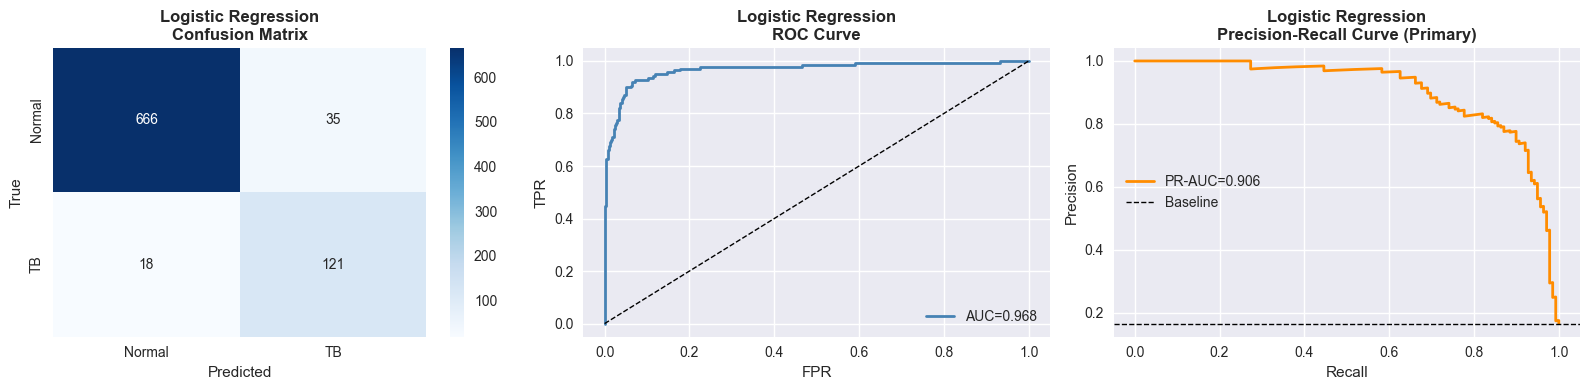

In [93]:
lr = LogisticRegression(
    C=1.0, max_iter=1000, class_weight="balanced",
    solver="lbfgs", random_state=RANDOM_STATE,
)
evaluate_model("Logistic Regression", lr, X_train_sc, y_train_sm, X_test_sc, y_test)
plot_evaluation(
    "Logistic Regression", y_test,
    results["Logistic Regression"]["y_pred"],
    results["Logistic Regression"]["y_prob"],
)


### Model 2 — K-Nearest Neighbours


  KNN
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       701
Tuberculosis       0.89      0.89      0.89       139

    accuracy                           0.96       840
   macro avg       0.94      0.94      0.94       840
weighted avg       0.96      0.96      0.96       840

  ROC-AUC : 0.9706   PR-AUC : 0.9173


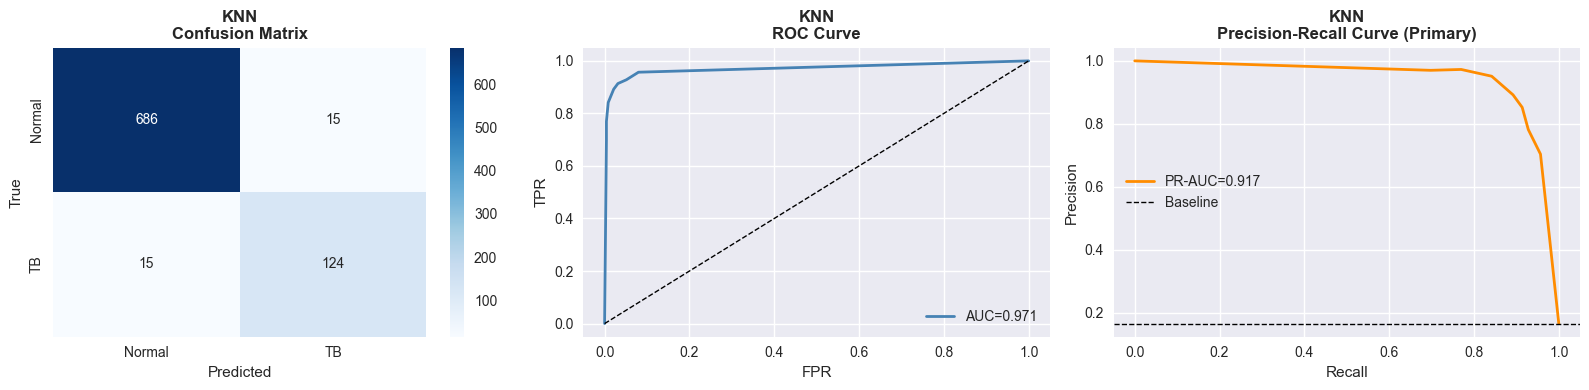

In [94]:
knn = KNeighborsClassifier(n_neighbors=7, metric="euclidean", n_jobs=-1)
evaluate_model("KNN", knn, X_train_sc, y_train_sm, X_test_sc, y_test)
plot_evaluation("KNN", y_test,
                results["KNN"]["y_pred"],
                results["KNN"]["y_prob"])


### Model 3 — Decision Tree


  Decision Tree
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96       701
Tuberculosis       0.79      0.86      0.82       139

    accuracy                           0.94       840
   macro avg       0.88      0.91      0.89       840
weighted avg       0.94      0.94      0.94       840

  ROC-AUC : 0.9233   PR-AUC : 0.8199


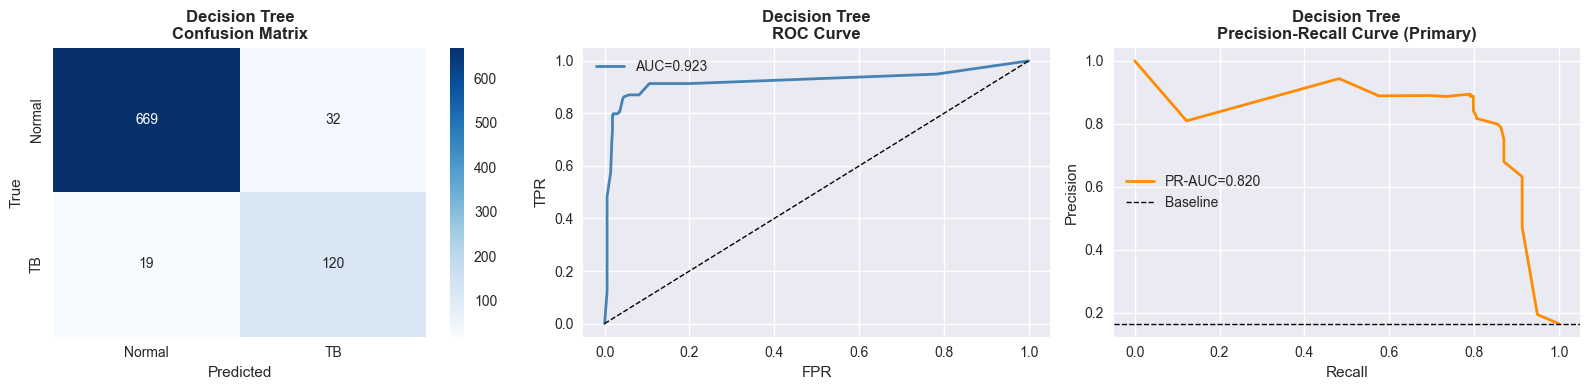

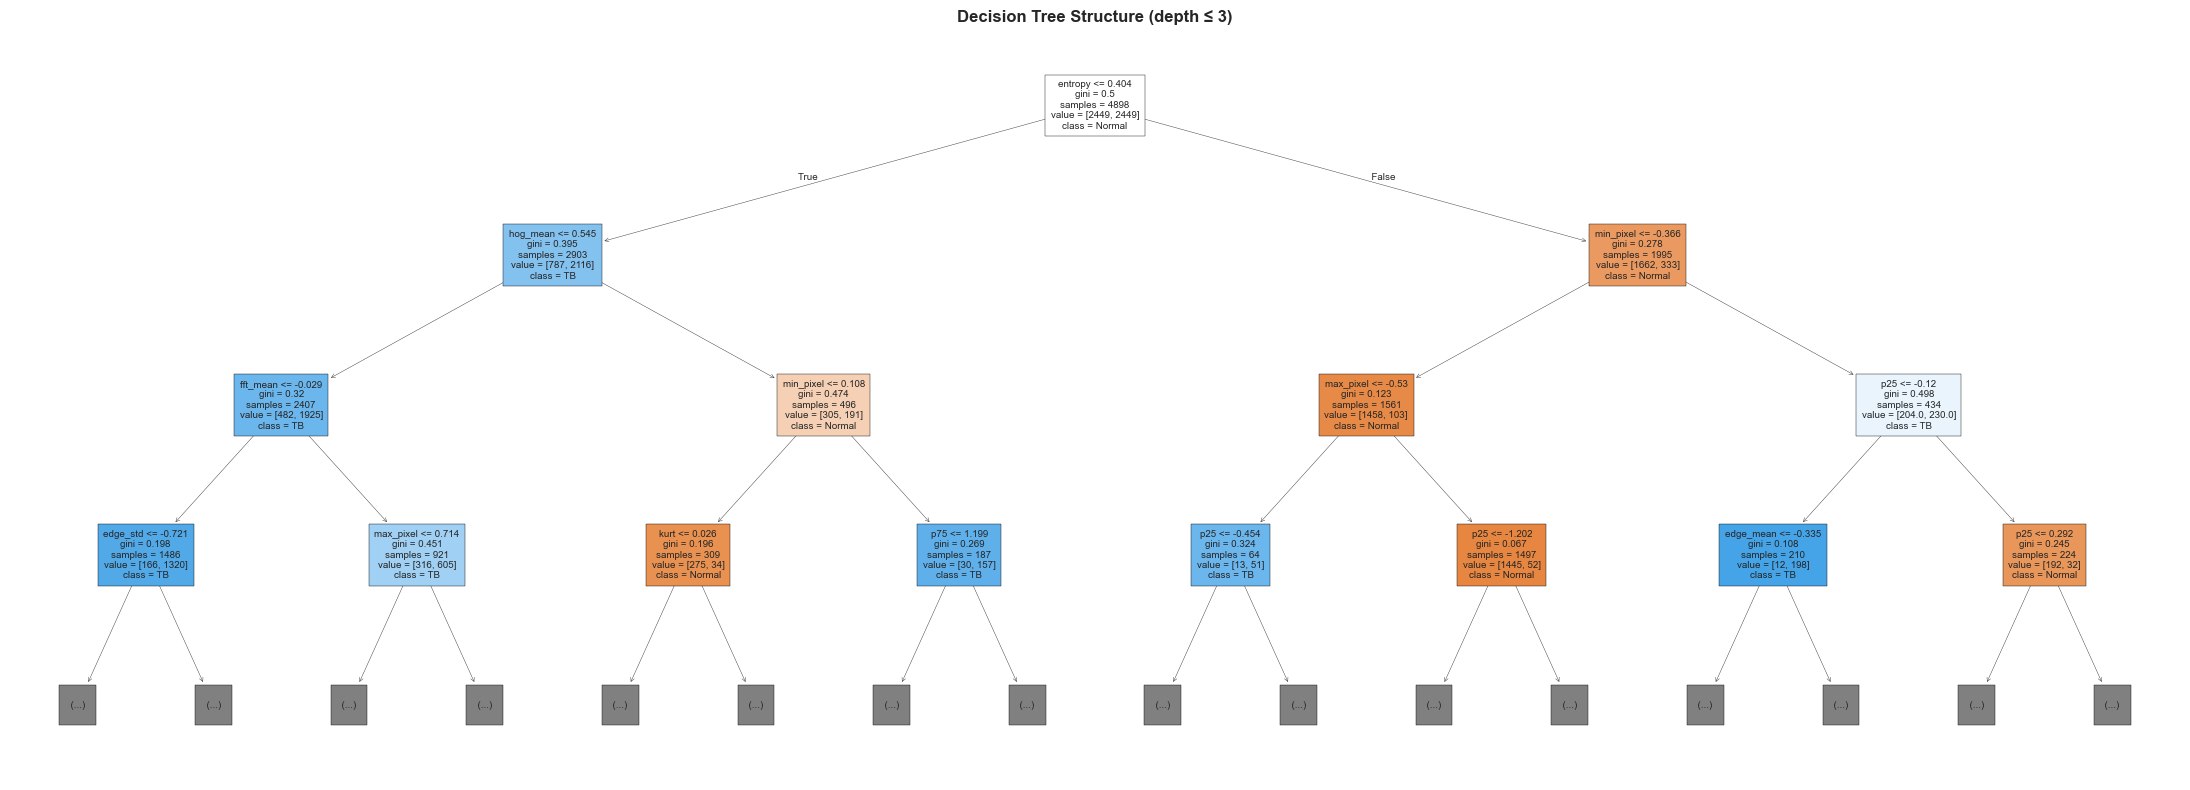

In [95]:
dt = DecisionTreeClassifier(
    max_depth=8, min_samples_split=10, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE,
)
evaluate_model("Decision Tree", dt, X_train_sc, y_train_sm, X_test_sc, y_test)
plot_evaluation("Decision Tree", y_test,
                results["Decision Tree"]["y_pred"],
                results["Decision Tree"]["y_prob"])

plt.figure(figsize=(22, 8))
plot_tree(dt, feature_names=FEATURE_NAMES, class_names=["Normal", "TB"],
          max_depth=3, filled=True, fontsize=7)
plt.title("Decision Tree Structure (depth ≤ 3)", fontweight="bold")
plt.tight_layout()
plt.savefig("dt_tree_viz.png", dpi=120, bbox_inches="tight")
plt.show()


### Model 4 — Random Forest


  Random Forest
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       701
Tuberculosis       0.95      0.94      0.95       139

    accuracy                           0.98       840
   macro avg       0.97      0.97      0.97       840
weighted avg       0.98      0.98      0.98       840

  ROC-AUC : 0.9908   PR-AUC : 0.9822


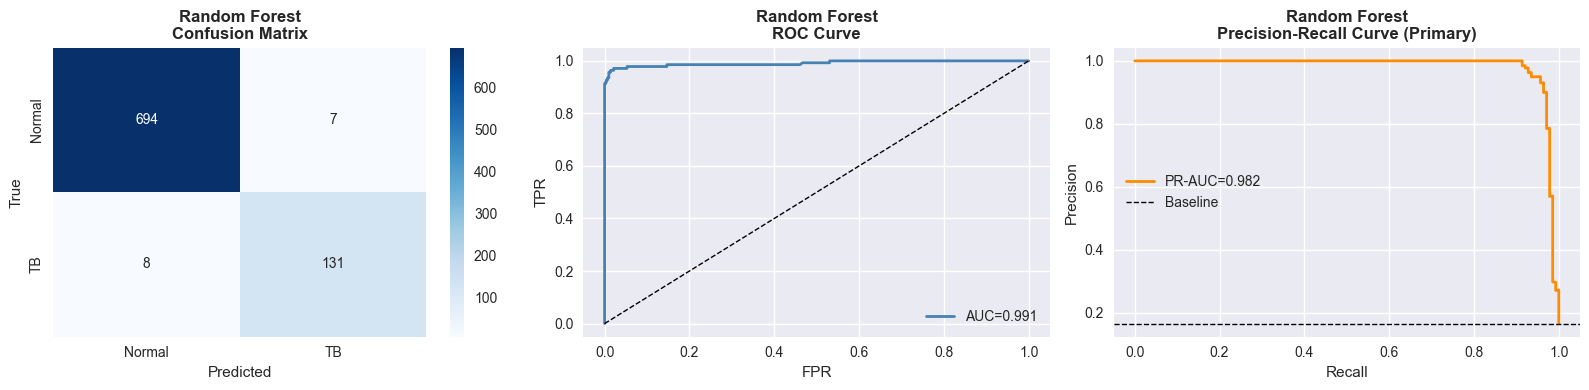

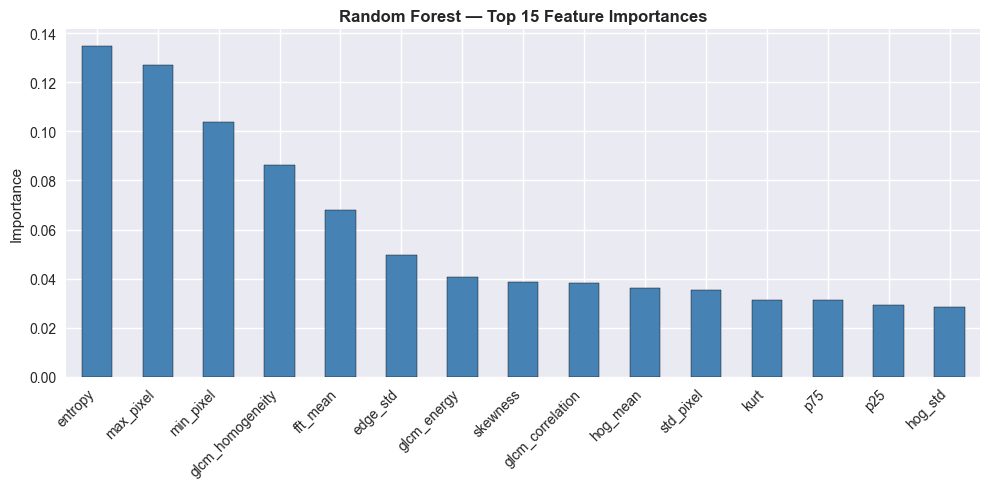

In [96]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=5,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
)
evaluate_model("Random Forest", rf, X_train_sc, y_train_sm, X_test_sc, y_test)
plot_evaluation("Random Forest", y_test,
                results["Random Forest"]["y_pred"],
                results["Random Forest"]["y_prob"])

fi = (
    pd.Series(rf.feature_importances_, index=FEATURE_NAMES)
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(10, 5))
fi.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Random Forest — Top 15 Feature Importances", fontweight="bold")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()


### Model 5 — XGBoost


  XGBoost
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       701
Tuberculosis       0.99      0.96      0.97       139

    accuracy                           0.99       840
   macro avg       0.99      0.98      0.98       840
weighted avg       0.99      0.99      0.99       840

  ROC-AUC : 0.9916   PR-AUC : 0.9865


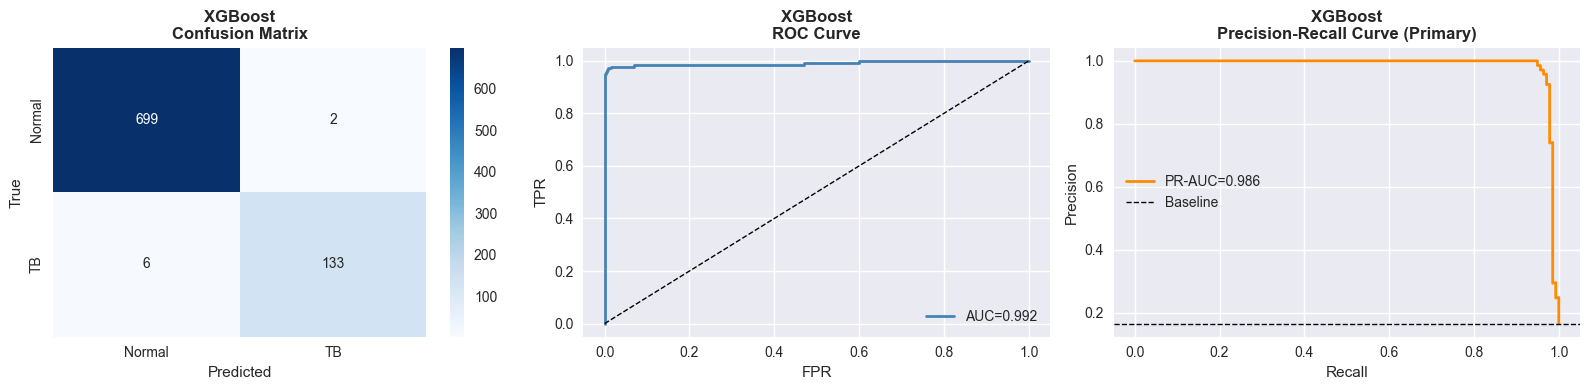

In [97]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,       # SMOTE already balanced the classes
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
evaluate_model("XGBoost", xgb_model, X_train_sc, y_train_sm, X_test_sc, y_test)
plot_evaluation("XGBoost", y_test,
                results["XGBoost"]["y_pred"],
                results["XGBoost"]["y_prob"])


### Model 6 — Support Vector Machine (SVM)


  SVM
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       701
Tuberculosis       0.98      0.93      0.96       139

    accuracy                           0.99       840
   macro avg       0.99      0.96      0.97       840
weighted avg       0.99      0.99      0.99       840

  ROC-AUC : 0.9849   PR-AUC : 0.9770


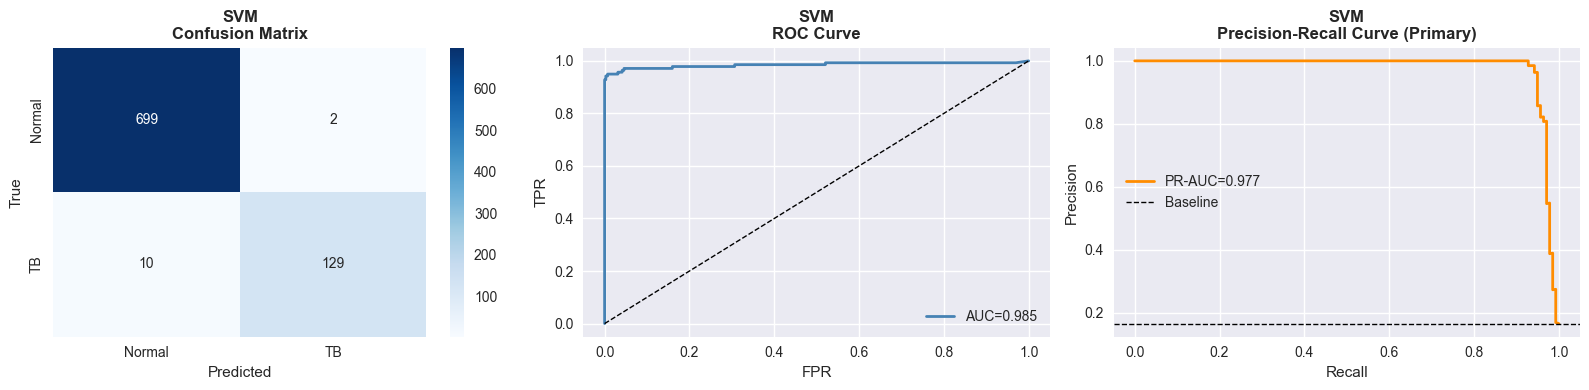

In [98]:
svm = SVC(
    kernel="rbf", C=10, gamma="scale",
    class_weight="balanced", probability=True,
    random_state=RANDOM_STATE,
)
evaluate_model("SVM", svm, X_train_sc, y_train_sm, X_test_sc, y_test)
plot_evaluation("SVM", y_test,
                results["SVM"]["y_pred"],
                results["SVM"]["y_prob"])


### Model 7 — Multi-Layer Perceptron (MLP)


  MLP
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       701
Tuberculosis       1.00      0.94      0.97       139

    accuracy                           0.99       840
   macro avg       0.99      0.97      0.98       840
weighted avg       0.99      0.99      0.99       840

  ROC-AUC : 0.9897   PR-AUC : 0.9837


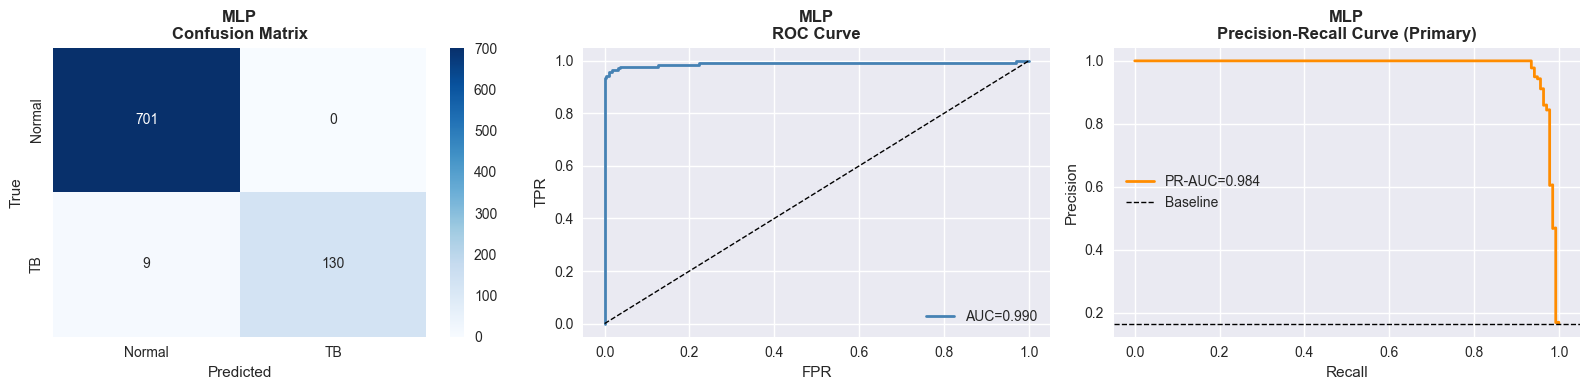

In [99]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation="relu",
    solver="adam",
    alpha=0.001,
    batch_size=64,
    learning_rate="adaptive",
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
)
evaluate_model("MLP", mlp, X_train_sc, y_train_sm, X_test_sc, y_test)
plot_evaluation("MLP", y_test,
                results["MLP"]["y_pred"],
                results["MLP"]["y_prob"])


### Model 8 — DenseNet-121 CNN with Focal Loss
> Transfer learning from ImageNet.  
> **Focal Loss** (γ=2, α=0.75) down-weights the easy Normal examples and forces  
> the optimiser to aggressively penalise missed TB cases.


In [100]:
#    Focal Loss definition 
def focal_loss(gamma=2.0, alpha=0.75):
    """
    Focal Loss (Lin et al., ICCV 2017).
    gamma  – modulating factor (higher = more focus on hard examples)
    alpha  – weight for the positive (TB) class; >0.5 penalises FN
    """
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
        bce    = -(y_true * tf.math.log(y_pred)
                   + (1 - y_true) * tf.math.log(1 - y_pred))
        p_t    = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        fl     = alpha_t * tf.pow(1 - p_t, gamma) * bce
        return tf.reduce_mean(fl)
    return loss_fn

print(" Focal Loss defined (gamma=2.0, alpha=0.75)")


 Focal Loss defined (gamma=2.0, alpha=0.75)


In [101]:
#  Image data generators 
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05,
    brightness_range=[0.9, 1.1],
)
val_datagen  = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

df_gen = df[["image_path", "label"]].rename(
    columns={"image_path": "filename", "label": "class"}
)
df_tr_g, df_te_g = train_test_split(
    df_gen, test_size=TEST_SIZE, stratify=df_gen["class"],
    random_state=RANDOM_STATE,
)
df_tr_g, df_va_g = train_test_split(
    df_tr_g, test_size=0.125, stratify=df_tr_g["class"],
    random_state=RANDOM_STATE,
)

flow_kw = dict(
    x_col="filename", y_col="class",
    target_size=(IMG_SIZE_CNN, IMG_SIZE_CNN),
    batch_size=BATCH_SIZE, class_mode="binary",
)
train_flow = train_datagen.flow_from_dataframe(df_tr_g, shuffle=True,  **flow_kw)
val_flow   = val_datagen.flow_from_dataframe  (df_va_g, shuffle=False, **flow_kw)
test_flow  = test_datagen.flow_from_dataframe (df_te_g, shuffle=False, **flow_kw)

print(f"CNN  Train: {len(df_tr_g)}  Val: {len(df_va_g)}  Test: {len(df_te_g)}")


Found 2937 validated image filenames belonging to 2 classes.
Found 420 validated image filenames belonging to 2 classes.
Found 840 validated image filenames belonging to 2 classes.
CNN  Train: 2937  Val: 420  Test: 840


In [102]:
#  DenseNet-121 architecture 
def build_model(input_shape=(IMG_SIZE_CNN, IMG_SIZE_CNN, 3)):
    base = DenseNet121(
        include_top=False, weights="imagenet", input_shape=input_shape
    )
    for layer in base.layers[:-30]:          # freeze bottom layers
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)
    x = Dense(64,  activation="relu")(x)
    x = Dropout(0.2)(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inputs=base.input, outputs=out)

cnn_model = build_model()
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
    ],
)
print(f"Model parameters: {cnn_model.count_params():,}")
cnn_model.summary()


Model parameters: 7,320,513


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,320,513 (27.93 MB)

 Trainable params: 922,369 (3.52 MB)

 Non-trainable params: 6,398,144 (24.41 MB)

In [103]:
#    Train 
cbs = [
    EarlyStopping(monitor="val_pr_auc", patience=8, mode="max",
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint("best_cnn.keras", monitor="val_pr_auc",
                    save_best_only=True, mode="max", verbose=0),
]

history = cnn_model.fit(
    train_flow, validation_data=val_flow,
    epochs=EPOCHS, callbacks=cbs, verbose=1,
)
print("\n CNN training complete.")


Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 390s 4s/step - accuracy: 0.7452 - loss: 0.0711 - pr_auc: 0.4911 - precision: 0.3292 - recall: 0.5850 - roc_auc: 0.7285 - val_accuracy: 0.9143 - val_loss: 0.0358 - val_pr_auc: 0.9486 - val_precision: 1.0000 - val_recall: 0.4857 - val_roc_auc: 0.9837 - learning_rate: 1.0000e-04
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 365s 4s/step - accuracy: 0.9189 - loss: 0.0209 - pr_auc: 0.8796 - precision: 0.6968 - recall: 0.8997 - roc_auc: 0.9691 - val_accuracy: 0.9786 - val_loss: 0.0119 - val_pr_auc: 0.9877 - val_precision: 1.0000 - val_recall: 0.8714 - val_roc_auc: 0.9957 - learning_rate: 1.0000e-04
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 377s 4s/step - accuracy: 0.9507 - loss: 0.0126 - pr_auc: 0.9507 - precision: 0.8004 - recall: 0.9234 - roc_auc: 0.9869 - val_accuracy: 0.9929 - val_loss: 0.0066 - val_pr_auc: 0.9918 - val_precision: 1.0000 - val_recall: 0.9571 - val_roc_auc: 0.9975 - learning_rate: 1.0000e-04
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 480s 5s/step - ac

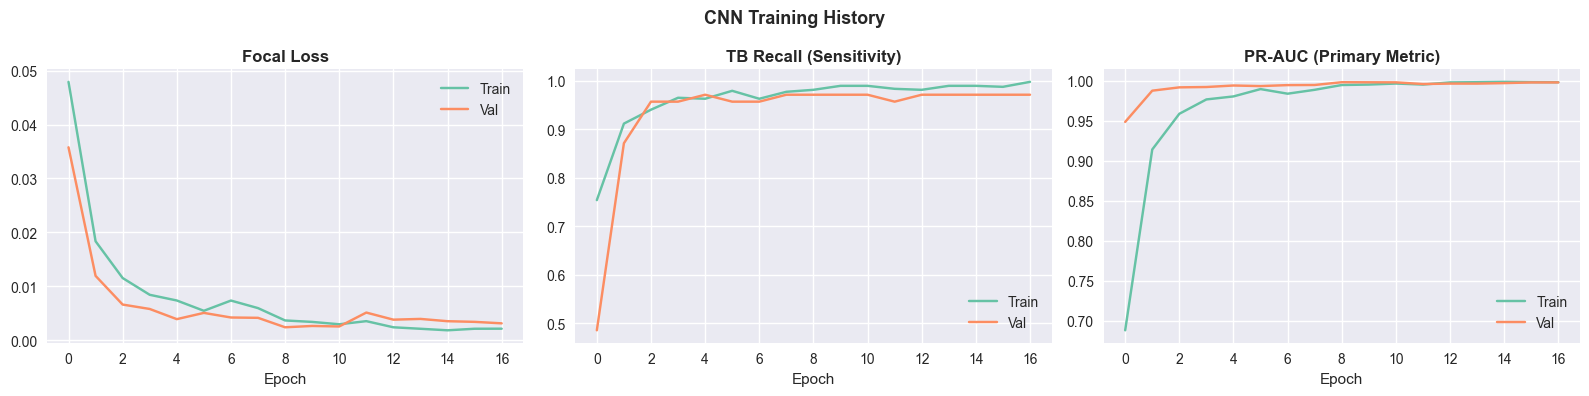

In [104]:
#   Training curves 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
h = history.history

axes[0].plot(h["loss"],        label="Train"); axes[0].plot(h["val_loss"],    label="Val")
axes[0].set_title("Focal Loss", fontweight="bold"); axes[0].legend()

axes[1].plot(h["recall"],      label="Train"); axes[1].plot(h["val_recall"],  label="Val")
axes[1].set_title("TB Recall (Sensitivity)", fontweight="bold"); axes[1].legend()

axes[2].plot(h["pr_auc"],      label="Train"); axes[2].plot(h["val_pr_auc"], label="Val")
axes[2].set_title("PR-AUC (Primary Metric)", fontweight="bold"); axes[2].legend()

for ax in axes:
    ax.set_xlabel("Epoch")

plt.suptitle("CNN Training History", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cnn_training.png", dpi=120, bbox_inches="tight")
plt.show()


              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       701
Tuberculosis       0.99      0.98      0.98       139

    accuracy                           0.99       840
   macro avg       0.99      0.99      0.99       840
weighted avg       0.99      0.99      0.99       840

ROC-AUC: 0.9993   PR-AUC: 0.9968


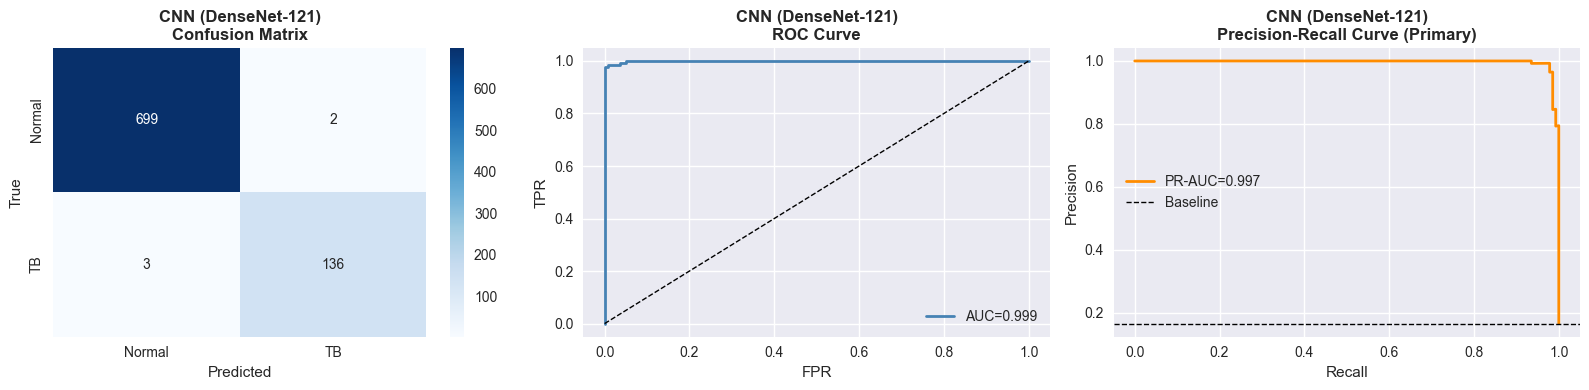

In [105]:
#  Evaluate CNN 
y_prob_cnn = cnn_model.predict(test_flow, verbose=0).flatten()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)
y_test_cnn = test_flow.labels

cnn_metrics = dict(
    accuracy  = accuracy_score(y_test_cnn, y_pred_cnn),
    precision = precision_score(y_test_cnn, y_pred_cnn, zero_division=0),
    recall    = recall_score(y_test_cnn, y_pred_cnn, zero_division=0),
    f1        = f1_score(y_test_cnn, y_pred_cnn, zero_division=0),
    roc_auc   = roc_auc_score(y_test_cnn, y_prob_cnn),
    pr_auc    = average_precision_score(y_test_cnn, y_prob_cnn),
)
results["CNN (DenseNet-121)"] = dict(
    model=cnn_model, y_pred=y_pred_cnn,
    y_prob=y_prob_cnn, **cnn_metrics
)

print(classification_report(y_test_cnn, y_pred_cnn,
                             target_names=["Normal", "Tuberculosis"]))
print(f"ROC-AUC: {cnn_metrics['roc_auc']:.4f}   PR-AUC: {cnn_metrics['pr_auc']:.4f}")
plot_evaluation("CNN (DenseNet-121)", y_test_cnn, y_pred_cnn, y_prob_cnn)


##  Model Comparison — Baseline Ladder

In [106]:
METRIC_KEYS = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
METRIC_LABELS = {
    "accuracy" : "Accuracy",
    "precision": "Precision",
    "recall"   : "Recall (TB ↑)",
    "f1"       : "F1-Score",
    "roc_auc"  : "ROC-AUC",
    "pr_auc"   : "PR-AUC (↑)",
}

comparison = (
    pd.DataFrame(
        {name: {k: v for k, v in res.items() if k in METRIC_KEYS}
         for name, res in results.items()}
    )
    .T
    .rename(columns=METRIC_LABELS)
    .round(4)
)
comparison.index.name = "Model"
print("\n" + "=" * 72)
print("  MODEL COMPARISON — sorted by PR-AUC (primary imbalance-aware metric)")
print("=" * 72)
print(comparison.sort_values("PR-AUC (↑)", ascending=False).to_string())



  MODEL COMPARISON — sorted by PR-AUC (primary imbalance-aware metric)
                     Accuracy  Precision  Recall (TB ↑)  F1-Score  ROC-AUC  PR-AUC (↑)
Model                                                                                 
CNN (DenseNet-121)     0.9940     0.9855         0.9784    0.9819   0.9993      0.9968
XGBoost                0.9905     0.9852         0.9568    0.9708   0.9916      0.9865
MLP                    0.9893     1.0000         0.9353    0.9665   0.9897      0.9837
Random Forest          0.9821     0.9493         0.9424    0.9458   0.9908      0.9822
SVM                    0.9857     0.9847         0.9281    0.9556   0.9849      0.9770
KNN                    0.9643     0.8921         0.8921    0.8921   0.9706      0.9173
Logistic Regression    0.9369     0.7756         0.8705    0.8203   0.9680      0.9062
Decision Tree          0.9393     0.7895         0.8633    0.8247   0.9233      0.8199


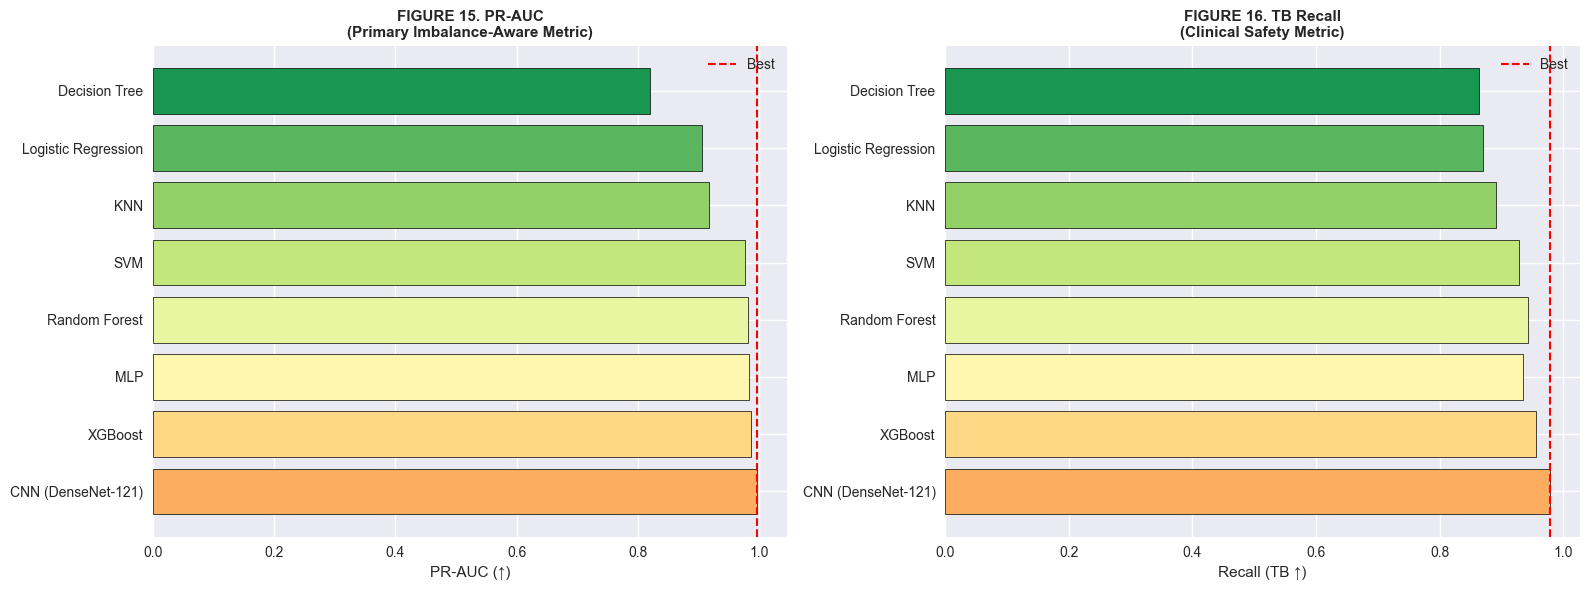

In [107]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
comp = comparison.sort_values("PR-AUC (↑)", ascending=False)
bar_colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(comp)))

for ax, col, title in [
    (axes[0], "PR-AUC (↑)",   "FIGURE 15. PR-AUC\n(Primary Imbalance-Aware Metric)"),
    (axes[1], "Recall (TB ↑)", "FIGURE 16. TB Recall\n(Clinical Safety Metric)"),
]:
    ax.barh(comp.index, comp[col], color=bar_colors, edgecolor="black", linewidth=0.5)
    ax.axvline(comp[col].iloc[0], color="red", linestyle="--", lw=1.5, label="Best")
    ax.set_xlabel(col, fontsize=11)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.legend()

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


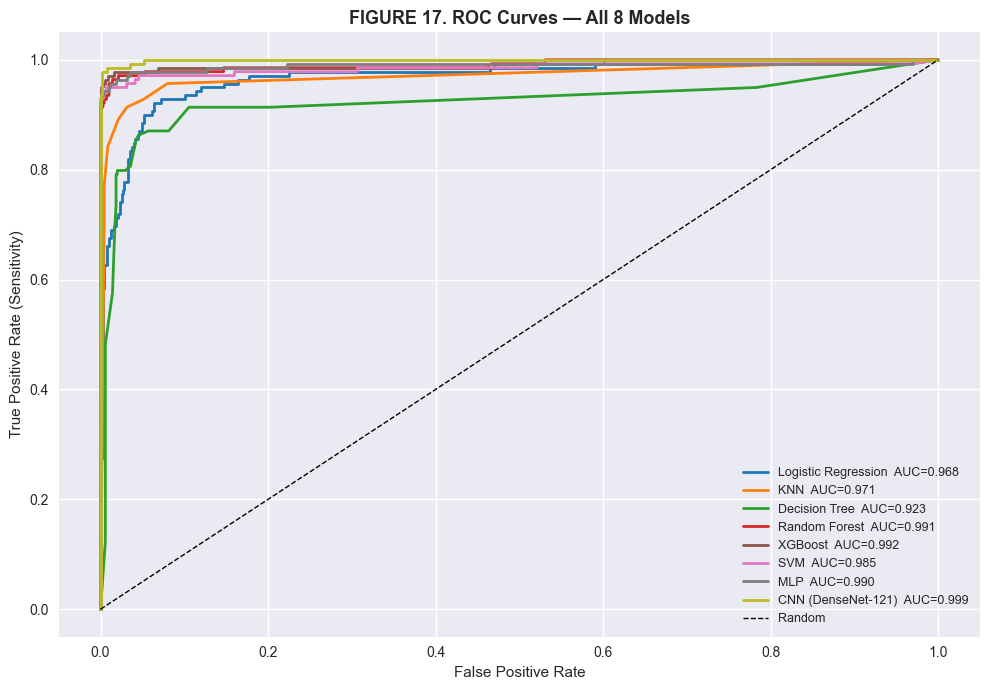

In [108]:
# All ROC curves on one plot
plt.figure(figsize=(10, 7))
cmap = plt.cm.tab10

for i, (name, res) in enumerate(results.items()):
    y_t = y_test_cnn if name == "CNN (DenseNet-121)" else y_test
    fpr, tpr, _ = roc_curve(y_t, res["y_prob"])
    plt.plot(fpr, tpr, lw=2,
             color=cmap(i / len(results)),
             label=f"{name}  AUC={res['roc_auc']:.3f}")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.title("FIGURE 17. ROC Curves — All 8 Models", fontweight="bold", fontsize=13)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("roc_all_models.png", dpi=150, bbox_inches="tight")
plt.show()


##  Explainable AI (XAI)

### XAI 8.1 — SHAP  *(Tree Models: Random Forest · XGBoost · Decision Tree)*

Computing SHAP values — Random Forest …


<Figure size 800x550 with 0 Axes>

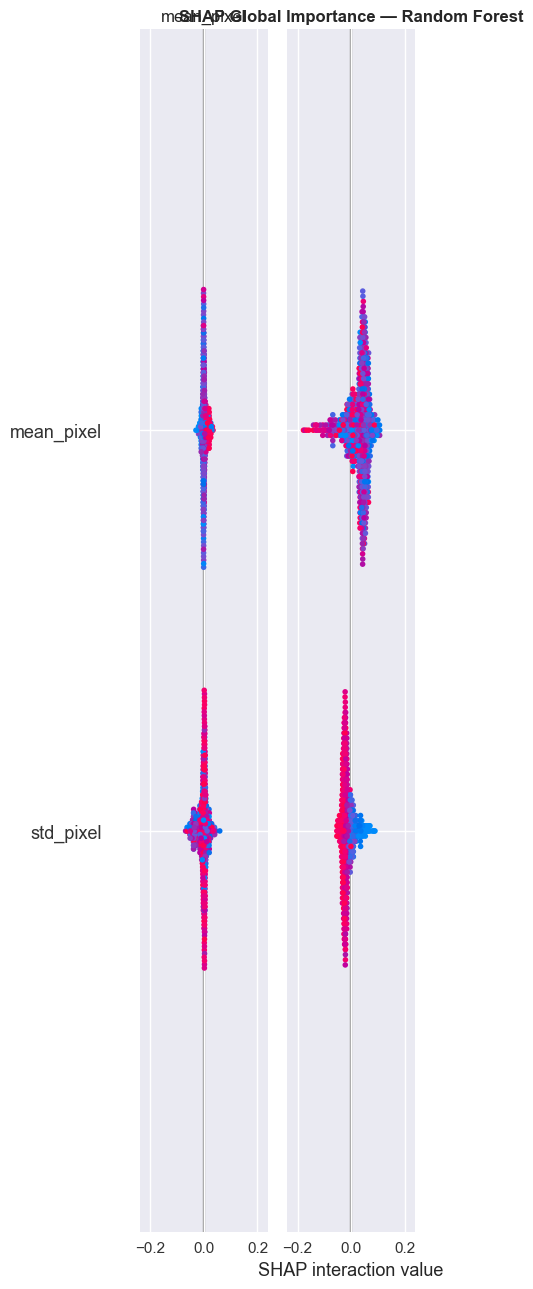

<Figure size 800x550 with 0 Axes>

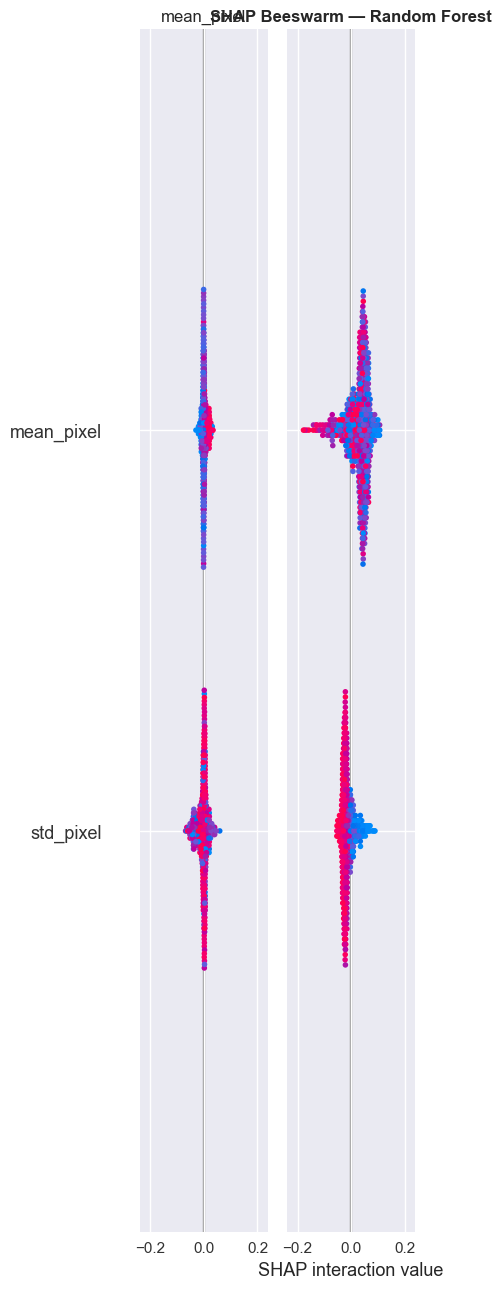

In [109]:
#  SHAP: Random Forest 
print("Computing SHAP values — Random Forest …")
exp_rf = shap.TreeExplainer(results["Random Forest"]["model"])
sv_rf_raw = exp_rf.shap_values(X_test_sc)
sv_rf = sv_rf_raw[1] if isinstance(sv_rf_raw, list) else sv_rf_raw

plt.figure()
shap.summary_plot(sv_rf, X_test_sc, feature_names=FEATURE_NAMES,
                  plot_type="bar", show=False, max_display=15)
plt.title("SHAP Global Importance — Random Forest", fontweight="bold")
plt.tight_layout(); plt.savefig("shap_rf_bar.png", dpi=120, bbox_inches="tight")
plt.show()

plt.figure()
shap.summary_plot(sv_rf, X_test_sc, feature_names=FEATURE_NAMES,
                  show=False, max_display=15)
plt.title("SHAP Beeswarm — Random Forest", fontweight="bold")
plt.tight_layout(); plt.savefig("shap_rf_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()


Computing SHAP values — XGBoost …


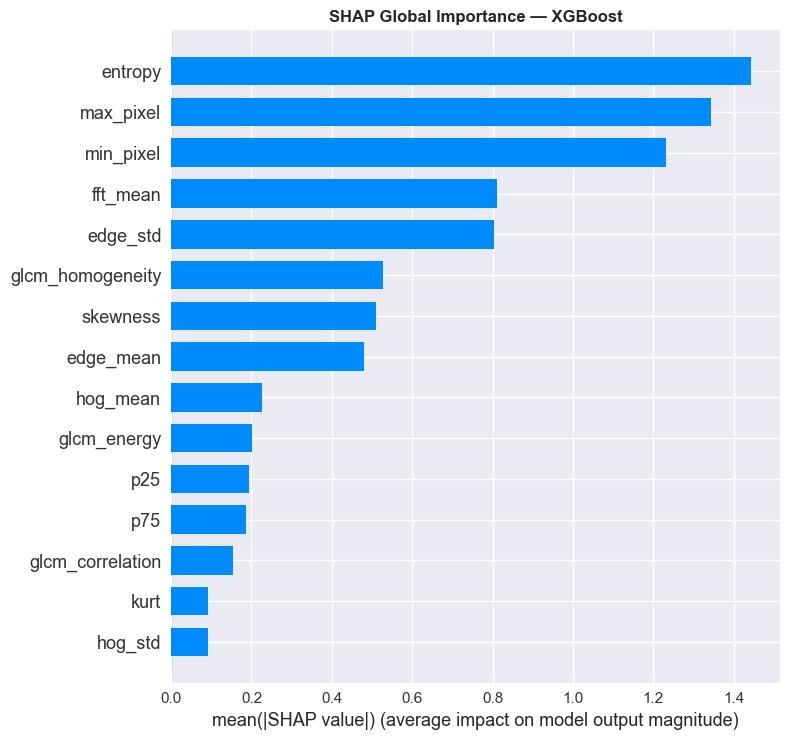

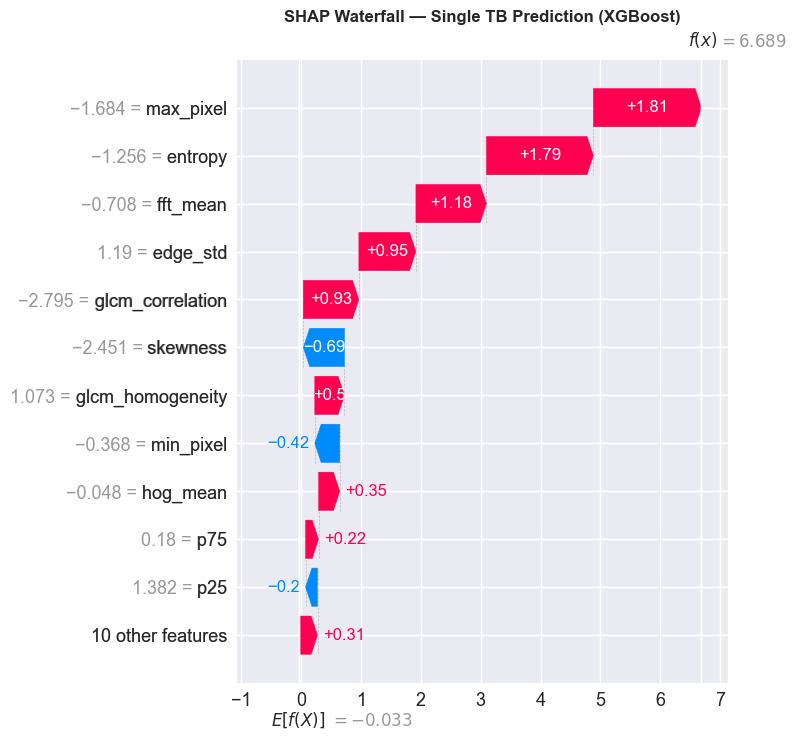

In [110]:
#  SHAP: XGBoost 
print("Computing SHAP values — XGBoost …")
exp_xgb = shap.TreeExplainer(results["XGBoost"]["model"])
sv_xgb  = exp_xgb.shap_values(X_test_sc)

plt.figure()
shap.summary_plot(sv_xgb, X_test_sc, feature_names=FEATURE_NAMES,
                  plot_type="bar", show=False, max_display=15)
plt.title("SHAP Global Importance — XGBoost", fontweight="bold")
plt.tight_layout(); plt.savefig("shap_xgb_bar.png", dpi=120, bbox_inches="tight")
plt.show()

# Waterfall for one TB sample
tb_idx = int(np.where(y_test == 1)[0][0])
shap_exp = shap.Explanation(
    values=sv_xgb[tb_idx],
    base_values=exp_xgb.expected_value,
    data=X_test_sc[tb_idx],
    feature_names=FEATURE_NAMES,
)
plt.figure()
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title("SHAP Waterfall — Single TB Prediction (XGBoost)", fontweight="bold")
plt.tight_layout(); plt.savefig("shap_xgb_waterfall.png", dpi=120, bbox_inches="tight")
plt.show()


Computing SHAP values — Decision Tree …


<Figure size 800x550 with 0 Axes>

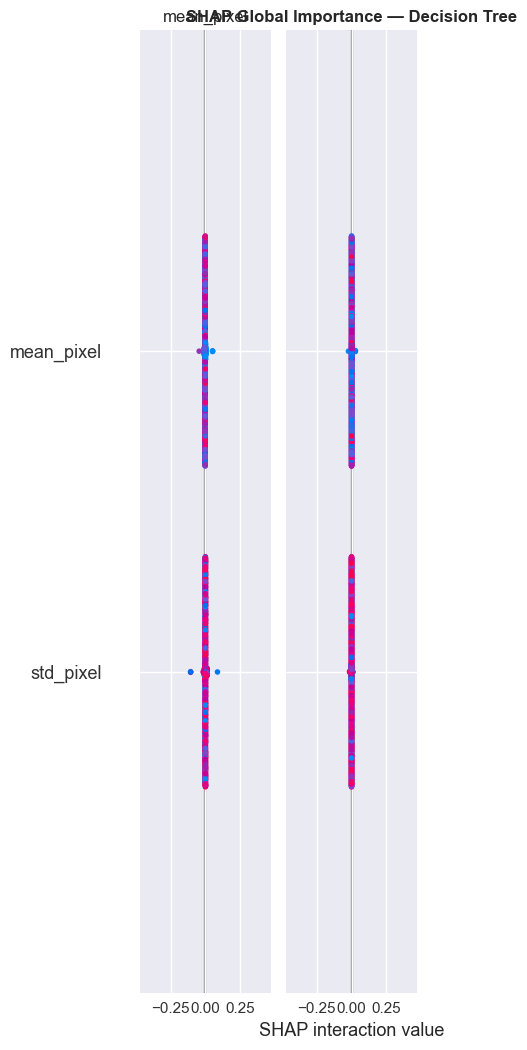

In [111]:
# SHAP: Decision Tree 
print("Computing SHAP values — Decision Tree …")
exp_dt   = shap.TreeExplainer(results["Decision Tree"]["model"])
sv_dt_raw = exp_dt.shap_values(X_test_sc)
sv_dt = sv_dt_raw[1] if isinstance(sv_dt_raw, list) else sv_dt_raw

plt.figure()
shap.summary_plot(sv_dt, X_test_sc, feature_names=FEATURE_NAMES,
                  plot_type="bar", show=False, max_display=12)
plt.title("SHAP Global Importance — Decision Tree", fontweight="bold")
plt.tight_layout(); plt.savefig("shap_dt_bar.png", dpi=120, bbox_inches="tight")
plt.show()


### XAI 8.2 — LIME  *(LR · KNN · SVM · MLP)*

Explaining test sample #30  (True label: Tuberculosis)


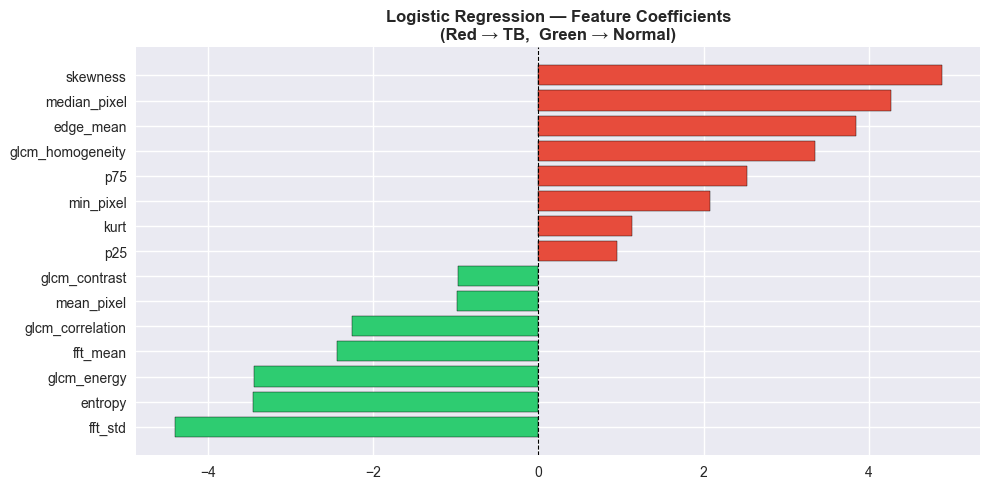


--- LIME: Logistic Regression ---


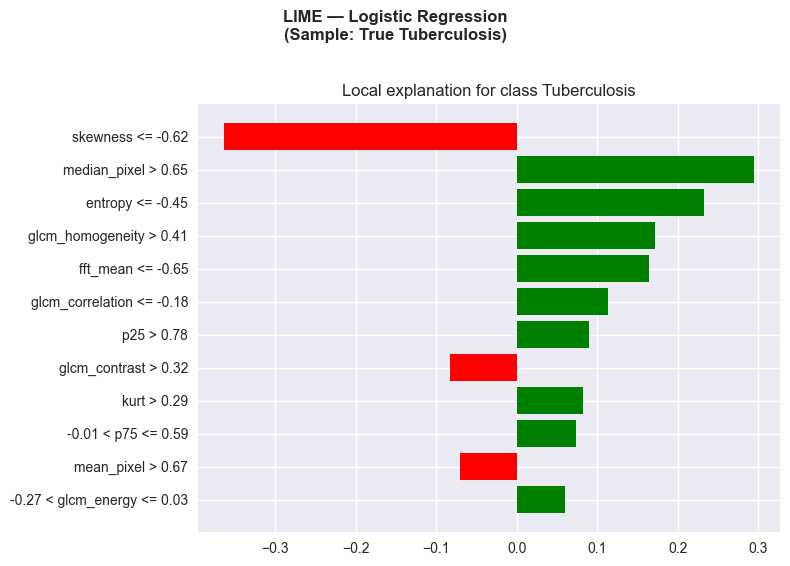

In [112]:
lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_sc,
    feature_names=FEATURE_NAMES,
    class_names=["Normal", "Tuberculosis"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

tb_idx = int(np.where(y_test == 1)[0][0])
print(f"Explaining test sample #{tb_idx}  (True label: Tuberculosis)")


def lime_explain(model_name, predictor, idx, n_feat=12):
    exp = lime_exp.explain_instance(
        X_test_sc[idx], predictor,
        num_features=n_feat, num_samples=1000, top_labels=1,
    )
    fig = exp.as_pyplot_figure(label=1)
    fig.suptitle(f"LIME — {model_name}\n(Sample: True Tuberculosis)",
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    safe = model_name.replace(" ", "_")
    plt.savefig(f"lime_{safe}.png", dpi=120, bbox_inches="tight")
    plt.show()
    return exp


# Logistic Regression also gets a coefficient plot
lr_model = results["Logistic Regression"]["model"]
coef_df = (
    pd.DataFrame({"Feature": FEATURE_NAMES, "Coef": lr_model.coef_[0]})
    .reindex(pd.Series(lr_model.coef_[0]).abs().nlargest(15).index)
    .sort_values("Coef")
)
colors = ["#e74c3c" if c > 0 else "#2ecc71" for c in coef_df["Coef"]]
plt.figure(figsize=(10, 5))
plt.barh(coef_df["Feature"], coef_df["Coef"], color=colors, edgecolor="black")
plt.axvline(0, color="black", lw=0.8, linestyle="--")
plt.title("Logistic Regression — Feature Coefficients\n"
          "(Red → TB,  Green → Normal)", fontweight="bold")
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n--- LIME: Logistic Regression ---")
lime_explain("Logistic Regression", lr_model.predict_proba, tb_idx)


--- LIME: KNN ---


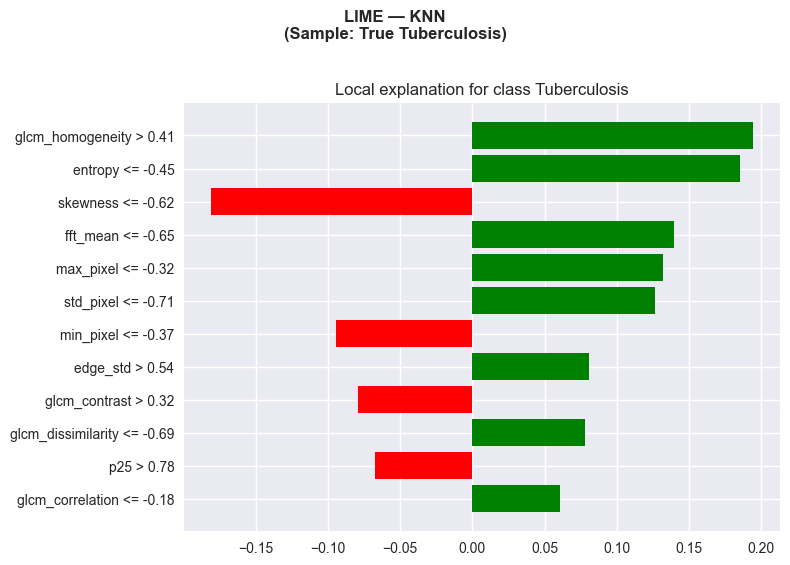

--- LIME: SVM ---


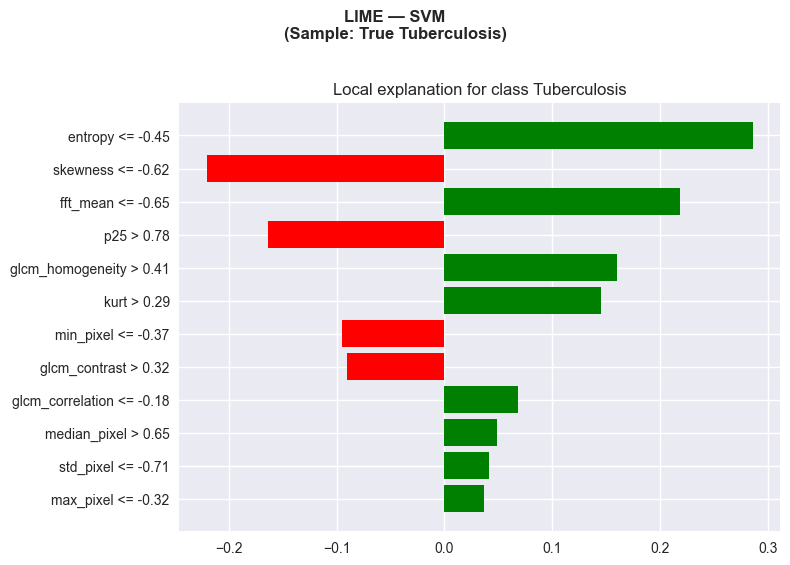

--- LIME: MLP ---


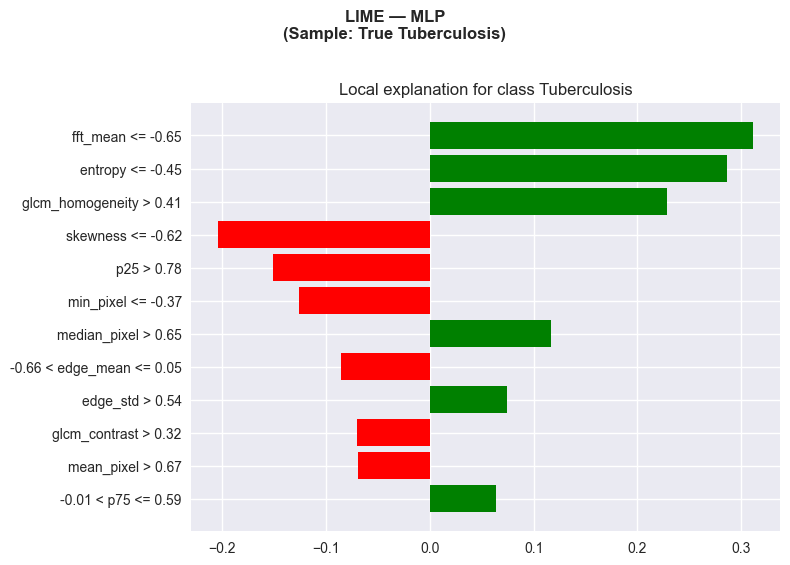

In [113]:
print("--- LIME: KNN ---")
lime_explain("KNN", results["KNN"]["model"].predict_proba, tb_idx)

print("--- LIME: SVM ---")
lime_explain("SVM", results["SVM"]["model"].predict_proba, tb_idx)

print("--- LIME: MLP ---")
lime_explain("MLP", results["MLP"]["model"].predict_proba, tb_idx)


### XAI 8.3 — Grad-CAM  *(DenseNet-121 CNN)*

In [114]:
#  Grad-CAM implementation 
def make_gradcam(img_array, model):
    """
    Gradient-weighted Class Activation Mapping.
    Highlights pulmonary regions driving the TB prediction.
    """
    last_conv = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name
            break

    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv).output, model.output],
    )
    with tf.GradientTape() as tape:
        img_t = tf.cast(img_array, tf.float32)
        conv_out, pred = grad_model(img_t)
        class_channel  = pred[:, 0]

    grads       = tape.gradient(class_channel, conv_out)
    pooled      = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap     = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap     = tf.squeeze(heatmap)
    heatmap     = tf.maximum(heatmap, 0)
    heatmap     = heatmap / (tf.reduce_max(heatmap) + K.epsilon())
    return heatmap.numpy()


def overlay_cam(img_path, model, alpha=0.4):
    orig_bgr    = cv2.imread(img_path)
    orig_rgb    = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    resized     = cv2.resize(orig_rgb, (IMG_SIZE_CNN, IMG_SIZE_CNN))
    img_arr     = np.expand_dims(resized / 255.0, axis=0)

    heatmap     = make_gradcam(img_arr, model)
    hmap_up     = cv2.resize(heatmap, (orig_rgb.shape[1], orig_rgb.shape[0]))
    colored     = cv2.applyColorMap(np.uint8(255 * hmap_up), cv2.COLORMAP_JET)
    colored_rgb = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    overlay     = (colored_rgb * alpha + orig_rgb * (1 - alpha)).astype(np.uint8)

    prob        = float(model.predict(img_arr, verbose=0)[0][0])
    label       = "Tuberculosis" if prob >= 0.5 else "Normal"
    return orig_rgb, hmap_up, overlay, label, prob


print(" Grad-CAM functions defined")


 Grad-CAM functions defined


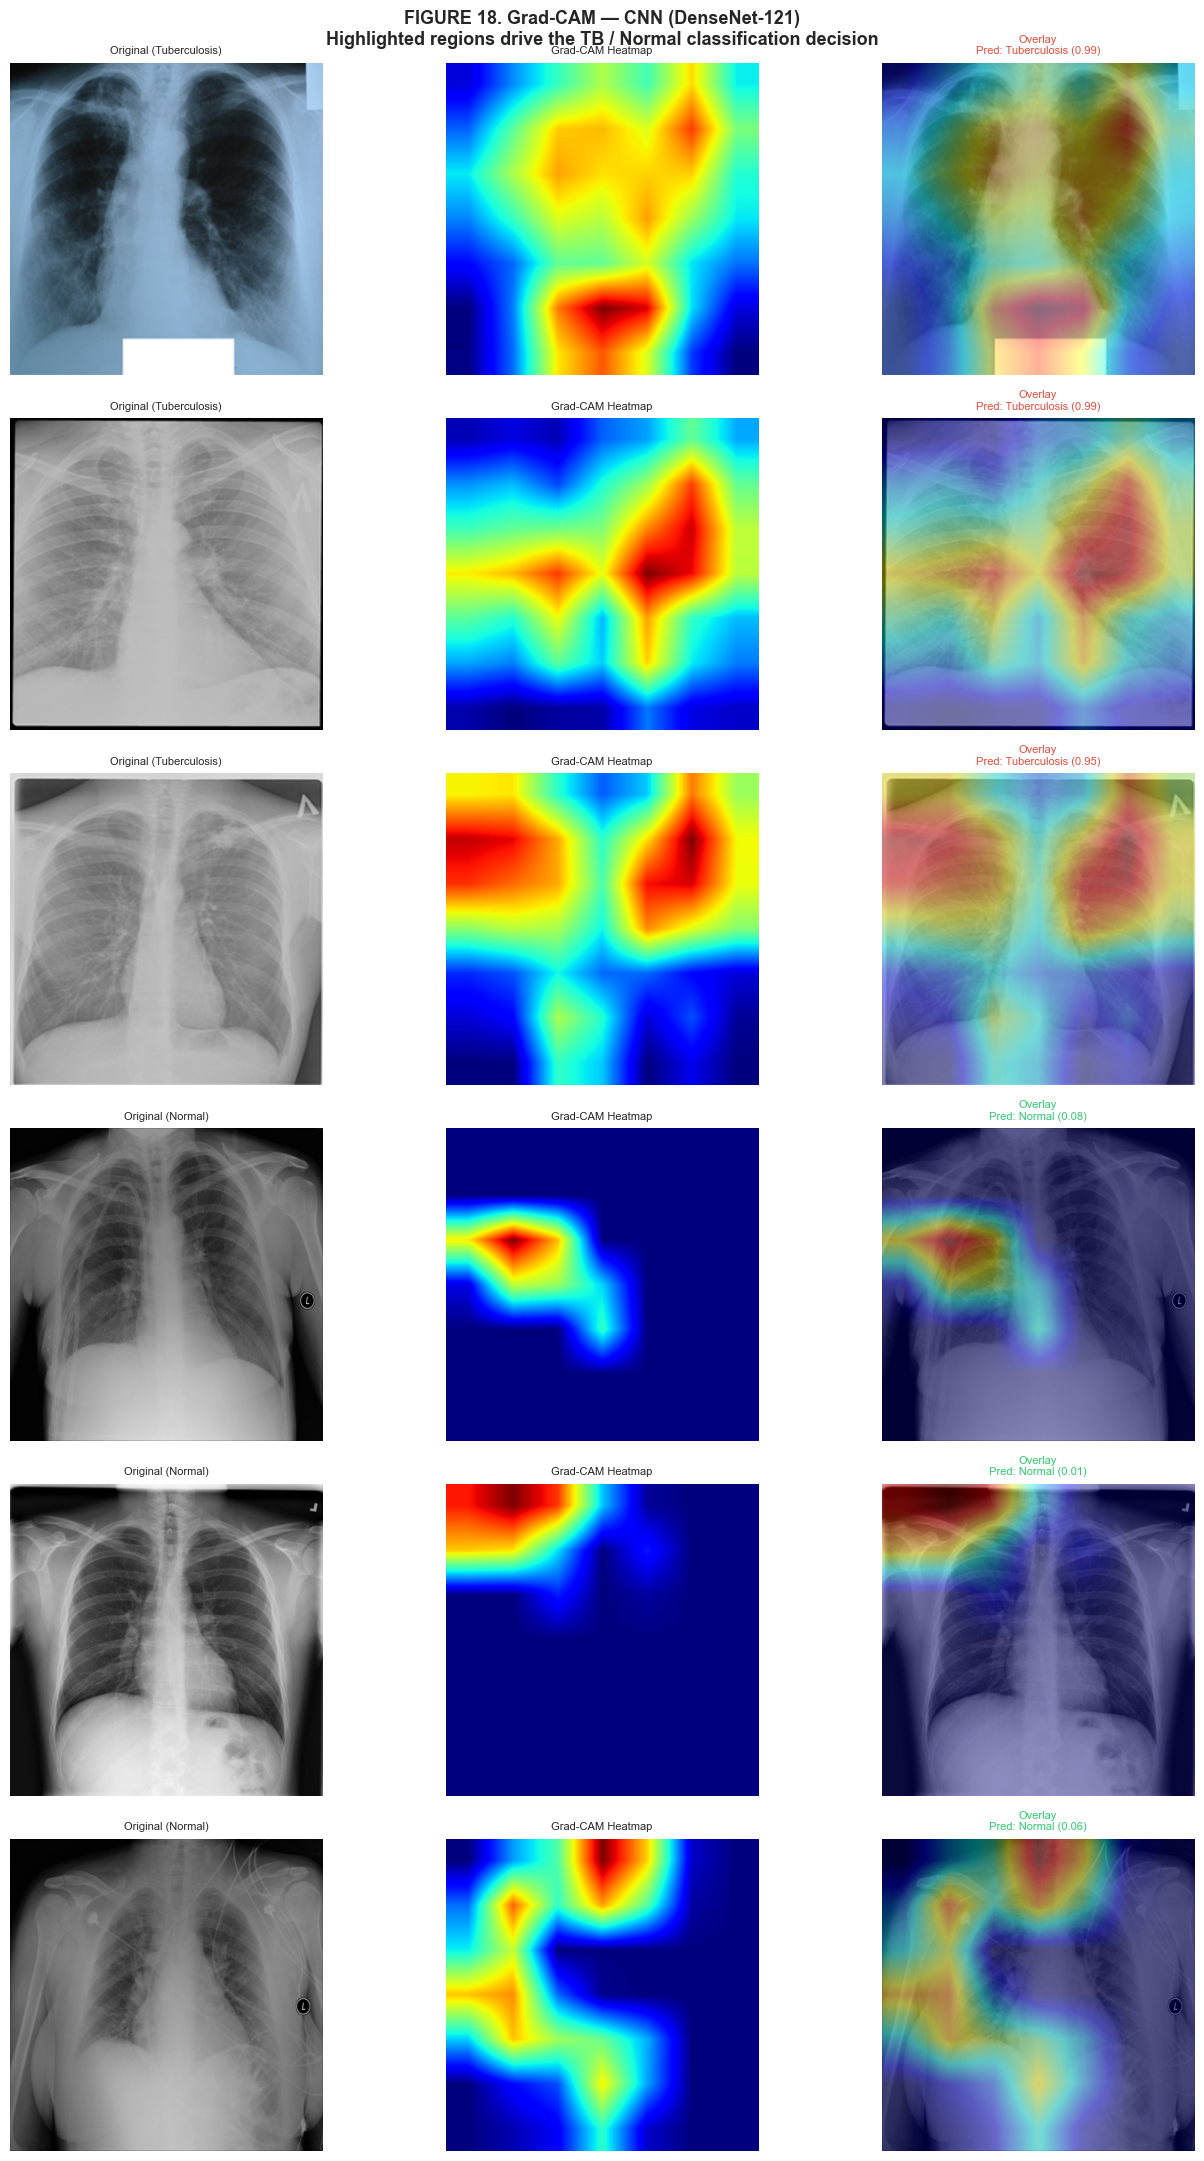


Grad-CAM complete


In [115]:
#  Apply Grad-CAM 
tb_paths  = df[df["label"] == "Tuberculosis"]["image_path"].head(3).tolist()
n_paths   = df[df["label"] == "Normal"]["image_path"].head(3).tolist()

fig, axes = plt.subplots(6, 3, figsize=(14, 22))
row = 0

for paths, true_lbl in [(tb_paths, "Tuberculosis"), (n_paths, "Normal")]:
    for ip in paths:
        orig, hmap, overlay, pred_lbl, prob = overlay_cam(ip, cnn_model)

        axes[row][0].imshow(orig); axes[row][0].set_title(f"Original ({true_lbl})", fontsize=8)
        axes[row][1].imshow(hmap, cmap="jet"); axes[row][1].set_title("Grad-CAM Heatmap", fontsize=8)
        axes[row][2].imshow(overlay)
        axes[row][2].set_title(
            f"Overlay\nPred: {pred_lbl} ({prob:.2f})",
            fontsize=8,
            color="#e74c3c" if pred_lbl == "Tuberculosis" else "#2ecc71",
        )
        for ax in axes[row]:
            ax.axis("off")
        row += 1

plt.suptitle(
    "FIGURE 18. Grad-CAM — CNN (DenseNet-121)\n"
    "Highlighted regions drive the TB / Normal classification decision",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig("gradcam.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nGrad-CAM complete")


##  Final Summary

In [116]:
sep = "=" * 75
print(sep)
print("  FINAL MODEL PERFORMANCE SUMMARY")
print("  (↑) = higher is better  |  Primary metrics: PR-AUC & TB Recall")
print(sep)

final = comparison.sort_values("PR-AUC (↑)", ascending=False)
print(final.to_string())

best = final.index[0]
print(f"\n Best model (PR-AUC)  : {best}")
for col in ["PR-AUC (↑)", "Recall (TB ↑)", "ROC-AUC", "F1-Score"]:
    print(f"   {col:<20}: {final.loc[best, col]:.4f}")

print("\n Pipeline complete:")
print("   Feature Extraction (21 feats) → EDA → 8 Models → Evaluation → XAI")


  FINAL MODEL PERFORMANCE SUMMARY
  (↑) = higher is better  |  Primary metrics: PR-AUC & TB Recall
                     Accuracy  Precision  Recall (TB ↑)  F1-Score  ROC-AUC  PR-AUC (↑)
Model                                                                                 
CNN (DenseNet-121)     0.9940     0.9855         0.9784    0.9819   0.9993      0.9968
XGBoost                0.9905     0.9852         0.9568    0.9708   0.9916      0.9865
MLP                    0.9893     1.0000         0.9353    0.9665   0.9897      0.9837
Random Forest          0.9821     0.9493         0.9424    0.9458   0.9908      0.9822
SVM                    0.9857     0.9847         0.9281    0.9556   0.9849      0.9770
KNN                    0.9643     0.8921         0.8921    0.8921   0.9706      0.9173
Logistic Regression    0.9369     0.7756         0.8705    0.8203   0.9680      0.9062
Decision Tree          0.9393     0.7895         0.8633    0.8247   0.9233      0.8199

 Best model (PR-AUC)  : CNN (D

In [117]:
import os
import pickle


# Directory to save models
SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)


# All trained models (make sure these variables exist from earlier cells!)
trained_models = {
    "Logistic Regression": lr,
    "K-Nearest Neighbors": knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb_model,
    "SVM": svm,
    "MLP Neural Network": mlp,
}

# 1. Save every individual model
print("Saving individual models...\n" + "─" * 50)

for name, model in trained_models.items():
    filename = name.lower().replace(" ", "_") + ".pkl"
    filepath = os.path.join(SAVE_DIR, filename)
    try:
        with open(filepath, "wb") as f:
            pickle.dump(model, f)
        print(f"Saved: {filepath}")
    except Exception as e:
        print(f"Failed to save {name}: {e}")


# 2. Save the scaler (very important for new data!)
scaler_path = os.path.join(SAVE_DIR, "scaler.pkl")
try:
    with open(scaler_path, "wb") as f:
        pickle.dump(scaler, f)
    print(f"Saved: {scaler_path}")
except Exception as e:
    print(f"Failed to save scaler: {e}")

# 3. Select and save the BEST model by PR-AUC
print("\nSelecting best model by PR-AUC...\n" + "─" * 50)

best_model_name = None
best_model = None

# Try common names people use for the results table
possible_df_names = [
    "results_df", "results", "df_results", "model_results",
    "performance_df", "scores_df", "metrics_df", "comparison_df",
    "eval_df", "model_comparison", "scores"
]

for var_name in possible_df_names:
    if var_name in globals() and isinstance(globals()[var_name], (type(pd.DataFrame()),)):
        df = globals()[var_name]
        if "PR-AUC" in df.columns and "Model" in df.columns:
            try:
                best_row = df.sort_values("PR-AUC", ascending=False).iloc[0]
                best_model_name = best_row["Model"]
                print(f"Found metrics in variable: {var_name!r}")
                print(f"Best model according to PR-AUC: {best_model_name}")
                break
            except Exception as e:
                print(f"Error while reading {var_name}: {e}")

# If we still didn't find it → fallback / warning
if best_model_name is None:
    print("\nWARNING: Could not find any DataFrame with 'Model' and 'PR-AUC' columns.")
    print("Possible reasons:")
    print("  • The comparison table cell was not run yet")
    print("  • The DataFrame has a different name")
    print("  • The column names are different (e.g. 'pr_auc', 'model_name')")
    print("\nPicking first model as fallback → almost certainly NOT the best choice!")
    if trained_models:
        best_model_name = list(trained_models.keys())[0]
        print(f"Fallback: using → {best_model_name}")
    else:
        print("No trained models available at all. Cannot save best model.")

# ── Save the best model if we have one 
if best_model_name and best_model_name in trained_models:
    best_model = trained_models[best_model_name]
    best_path = os.path.join(SAVE_DIR, "best_model.pkl")
    try:
        with open(best_path, "wb") as f:
            pickle.dump(best_model, f)
        print(f"\nBest model (PR-AUC): {best_model_name}")
        print(f"Saved as           : {best_path}")
    except Exception as e:
        print(f"Failed to save best model: {e}")
else:
    print("\nSkipping best_model.pkl — no valid best model determined.")

print("\n" + "═" * 60)
print("Model saving complete.")
print("═" * 60)

Saving individual models...
──────────────────────────────────────────────────
Saved: saved_models\logistic_regression.pkl
Saved: saved_models\k-nearest_neighbors.pkl
Saved: saved_models\decision_tree.pkl
Saved: saved_models\random_forest.pkl
Saved: saved_models\xgboost.pkl
Saved: saved_models\svm.pkl
Saved: saved_models\mlp_neural_network.pkl
Saved: saved_models\scaler.pkl

Selecting best model by PR-AUC...
──────────────────────────────────────────────────

Possible reasons:
  • The comparison table cell was not run yet
  • The DataFrame has a different name
  • The column names are different (e.g. 'pr_auc', 'model_name')

Picking first model as fallback → almost certainly NOT the best choice!
Fallback: using → Logistic Regression

Best model (PR-AUC): Logistic Regression
Saved as           : saved_models\best_model.pkl

════════════════════════════════════════════════════════════
Model saving complete.
════════════════════════════════════════════════════════════
